# Figure3

In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import matplotlib.colors as mcolors
from matplotlib import rcParams, rcParamsDefault
from matplotlib.lines import Line2D
from src.utils.tools import seed_everything

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']


/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# sns.set_palette("colorblind")
# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
# COLOR_MAP = {'H3K4me1':'#40A878','H3K4me3':'#86A1C0','H3K9me3':'#EEDCAD','H3K27ac':'#B09324','H3K27me3':'#498FC7','H3K36me3':'#A074A9','H3K9ac':'#D87469'}
COLOR_MAP = {'H3K9ac':'#5F7BB0','H3K27ac':'#E6867D','H3K4me3':'#77BBDE','H3K4me1':'#C189B3','H3K36me3':'#9AC984','H3K27me3':'#ECDC6B','H3K9me3':'#91CDC6'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


# Figure 3A

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/563270738.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/563270738.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


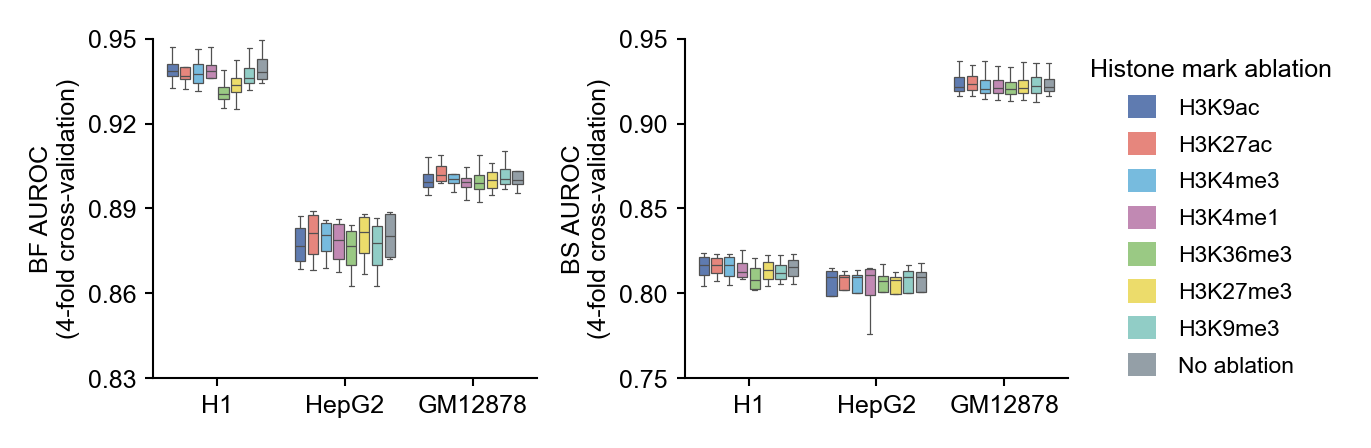

In [4]:
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(9/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')
palette = {k:COLOR_MAP[k.split('_')[1]] for k in hue_order if k.split('_')[1] in COLOR_MAP}
palette['all_marks'] = '#949FA7'

data =  pd.read_csv('extra/results/ablation_bf_para.csv',sep='\t')
data['auc'] = data['auc'] / 100



sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.2,width=0.8,order=order,hue_order=hue_order,linewidth=0.3,fliersize=0,
                 palette=palette,ax=ax[0],saturation=1)
ax[0].legend().remove()  # Moves the legend outside the plot
ax[0].set_ylabel('BF AUROC\n(4-fold cross-validation)')
ax[0].set_xlabel('')
# ax[0].set_title('Burst frequency',fontsize=6,fontweight='regular')
ax[0].set_ylim(0.83,0.95)
yticks = [i/100 for i in range(83,96,3)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)

data =  pd.read_csv('extra/results/ablation_bs_para.csv',sep='\t')
data['auc'] = data['auc'] / 100

sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.2,width=0.8,order=order,hue_order=hue_order,linewidth=0.3,fliersize=0,
                 palette=palette,ax=ax[1],saturation=1)

ax[1].legend().remove()  # Moves the legend outside the plot
ax[1].set_ylabel('BS AUROC\n(4-fold cross-validation)')
ax[1].set_xlabel('')
ax[1].set_ylim(0.75)
yticks = [i/100 for i in range(75,96,5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)
# ax[1].set_title('Burst size',fontsize=6,fontweight='regular')


handles, labels = ax[0].get_legend_handles_labels()
# ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","No ablation"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
legend = fig.legend(handles, labels, 
                    loc='upper left',
                    bbox_to_anchor=(0.99, 0.95), 
                    title_fontsize=6,
                    fontsize = 5.5,
                    title='Histone mark ablation',
                    ncol=1,
                    edgecolor='none',
                    handleheight=3/2.54, 
                    handlelength=3/2.54,
                    handletextpad=1.0,
                    labelspacing=1.5/2.54
                )


for handle in legend.legend_handles:
    if hasattr(handle, 'set_edgecolor'):
        handle.set_edgecolor('none')  # 柱状色块边框
    if hasattr(handle, 'set_linewidth'):
        handle.set_linewidth(0)

ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)
# fig.supxlabel('EID')

plt.savefig('extra/figures/v7/Figure3A.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 3B

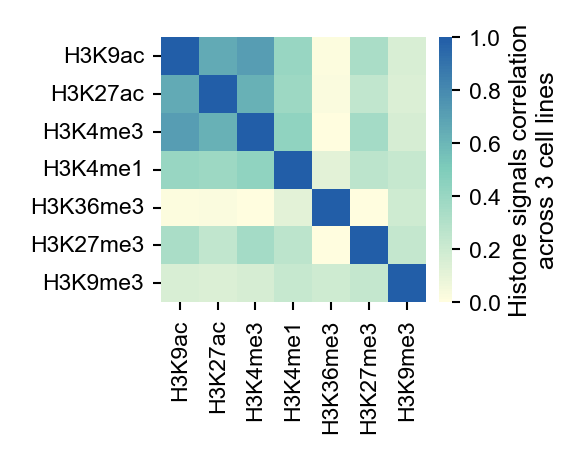

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

MARKS = ['H3K9ac', 'H3K27ac', 'H3K4me3', 'H3K4me1', 'H3K36me3', 'H3K27me3', 'H3K9me3']
COLORS = ['#FFFDDF', '#7FCDBB', '#225EA8']

correlation_E003 = np.loadtxt('extra/results/E003_hm_correlation.csv', delimiter=",")
correlation_E116 = np.loadtxt('extra/results/E116_hm_correlation.csv', delimiter=",")
correlation_E118 = np.loadtxt('extra/results/E118_hm_correlation.csv', delimiter=",")

correlation = (correlation_E003 + correlation_E116 + correlation_E118) / 3

# =========================================================
# SOURCE DATA
# =========================================================
records = []

for matrix_name, matrix, eid in [
    ('E003', correlation_E003, 'E003'),
    ('E116', correlation_E116, 'E116'),
    ('E118', correlation_E118, 'E118'),
    ('Average', correlation, 'Average'),
]:
    for i, mark_row in enumerate(MARKS):
        for j, mark_col in enumerate(MARKS):
            records.append({
                'matrix': matrix_name,
                'eid': eid,
                'cell_type': EIDS_TO_CELLTYPES[eid] if eid in EIDS_TO_CELLTYPES else 'Average across 3 cell lines',
                'mark_row': mark_row,
                'mark_col': mark_col,
                'correlation': matrix[i, j],
            })

source_data = pd.DataFrame(records)

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig3b.csv', index=False)

print(f'Source data saved to {source_dir}/fig3b.csv')

# =========================================================
# PLOT
# =========================================================
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.7/2.54, 4.7/2.54))

ax = sns.heatmap(correlation, cbar_kws={"shrink": 0.6, "fraction": 0.05}, vmin=0, vmax=1, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))

ax.set_xticklabels(MARKS, rotation=90, fontsize=5.5)
ax.set_yticklabels(MARKS, rotation=360, fontsize=5.5)
ax.set_aspect('equal')
ax.tick_params(axis='both', width=0.5)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(width=0.5, labelsize=5.5)
cbar.set_label('Histone signals correlation\nacross 3 cell lines', fontsize=6)

plt.savefig('extra/figures/v8/Figure3B.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 3C

Source data saved to scripts/figures/v8/source_data/fig3c.csv


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/3483887893.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/3483887893.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


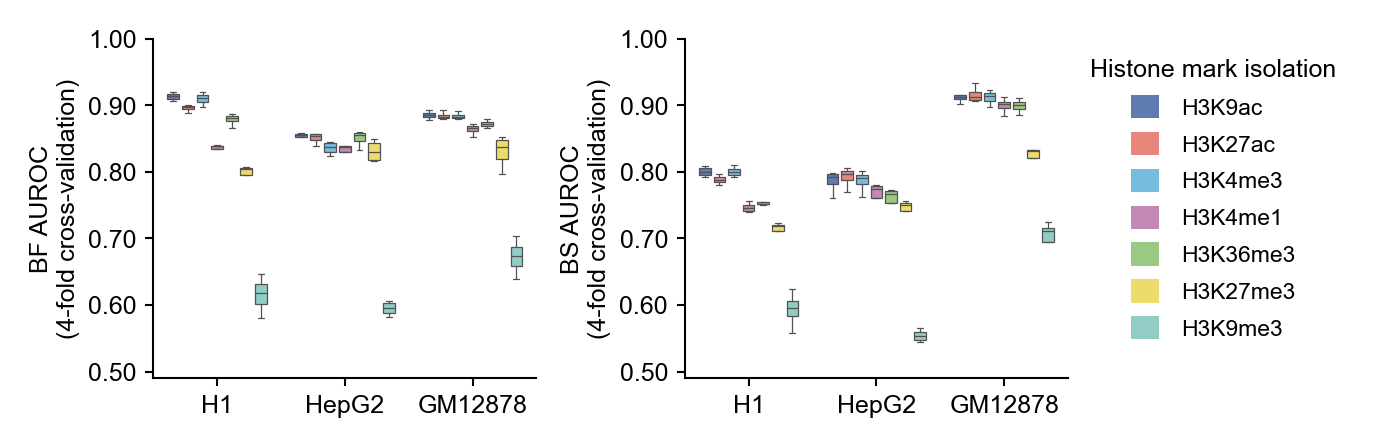

In [5]:
import os

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(9/2.54, 3.5/2.54))

hue_order = pd.Index(["H3K9ac", "H3K27ac", "H3K4me3", "H3K4me1", "H3K36me3", "H3K27me3", "H3K9me3"], name='marks')
order = pd.Index(["E003", "E118", "E116"], name='marks')

# =========================================================
# LOAD DATA
# =========================================================
data_bf = pd.read_csv('extra/results/one_feature_indicators_bf_para.csv')
data_bf['auc'] = data_bf['auc'] / 100
data_bf['target'] = 'BF'

data_bs = pd.read_csv('extra/results/one_feature_indicators_bs_para.csv')
data_bs['auc'] = data_bs['auc'] / 100
data_bs['target'] = 'BS'

# =========================================================
# SOURCE DATA
# =========================================================
source_data = pd.concat([data_bf, data_bs], ignore_index=True)
source_data['cell_type'] = source_data['eid'].map(EIDS_TO_CELLTYPES)

source_columns = ['eid', 'cell_type', 'target', 'keep_mark', 'fold', 'auc']
source_data = source_data[[col for col in source_columns if col in source_data.columns]]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig3c.csv', index=False)

print(f'Source data saved to {source_dir}/fig3c.csv')

# =========================================================
# BF PANEL
# =========================================================
sns.boxplot(data=data_bf, y='auc', x='eid', hue='keep_mark', gap=0.2, width=0.8, order=order, hue_order=hue_order, linewidth=0.3, fliersize=0, palette=COLOR_MAP, ax=ax[0], saturation=1)

ax[0].set_ylabel('BF AUROC\n(4-fold cross-validation)')
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_ylim(0.49)

yticks = [i/100 for i in range(50, 101, 10)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)

# =========================================================
# BS PANEL
# =========================================================
sns.boxplot(data=data_bs, y='auc', x='eid', hue='keep_mark', gap=0.2, width=0.8, order=order, hue_order=hue_order, linewidth=0.3, fliersize=0, palette=COLOR_MAP, ax=ax[1], saturation=1)

ax[1].set_ylabel('BS AUROC\n(4-fold cross-validation)')
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_ylim(0.49)

yticks = [i/100 for i in range(50, 101, 10)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)

# =========================================================
# LEGEND
# =========================================================
handles, labels = ax[0].get_legend_handles_labels()

legend = fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.99, 0.95), title_fontsize=6, fontsize=5.5, title='Histone mark isolation', ncol=1, edgecolor='none', handleheight=3/2.54, handlelength=3/2.54, handletextpad=1.0, labelspacing=1.5/2.54)

for handle in legend.legend_handles:
    if hasattr(handle, 'set_edgecolor'):
        handle.set_edgecolor('none')
    if hasattr(handle, 'set_linewidth'):
        handle.set_linewidth(0)

plt.savefig('extra/figures/v8/Figure3C.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 3D

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/829182002.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/829182002.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


Source data saved to scripts/figures/v8/source_data/fig3d.csv


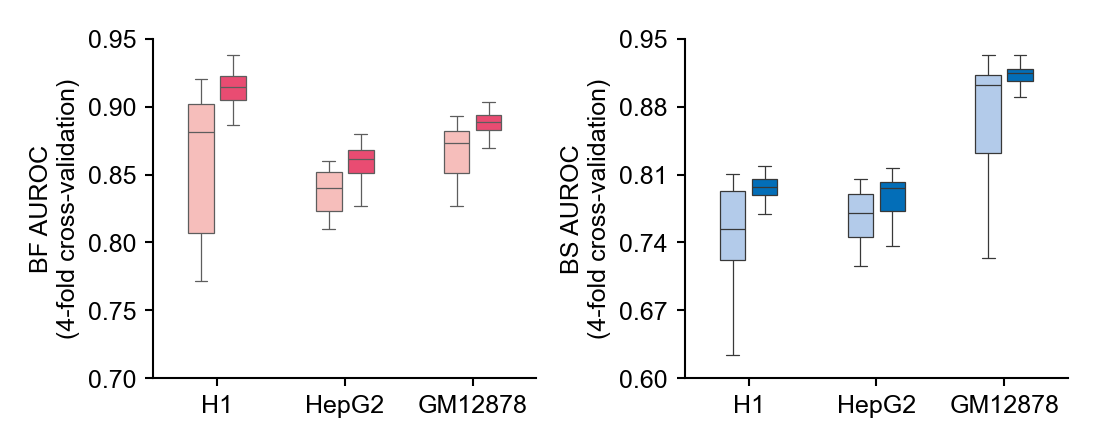

In [6]:
import os

target = 'bf'
MARKS = ['H3K9ac', 'H3K27ac', 'H3K4me3', 'H3K4me1', 'H3K36me3', 'H3K27me3', 'H3K9me3']
hue_order = ['single_mark', 'combine_mark']
order = ['E003', 'E118', 'E116']

data_bf = pd.DataFrame({})
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(9/2.54, 3.5/2.54))

for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid', 'keep_marks', 'fold', 'auc']]

    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark), axis=1)
    data1['type'] = 'combine_mark'

    data2 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[data2['keep_mark'] == keep_mark]
    data2.columns = ['eid', 'keep_marks', 'fold', 'auc']
    data2['type'] = 'single_mark'

    data_bf = pd.concat([data_bf, data1, data2], axis=0)

data_bf['auc'] = data_bf['auc'] / 100

palette = ['#F6BEBB', '#E94C72']
sns.boxplot(data=data_bf, x='eid', y='auc', hue='type', fliersize=0, linewidth=0.3, gap=0.2, width=0.5, order=order, hue_order=hue_order, palette=palette, ax=ax[0], saturation=1)

ax[0].set_xlabel('')
ax[0].set_ylabel('BF AUROC\n(4-fold cross-validation)', fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_ylim(0.70, 0.95)

yticks = [i/100 for i in range(70, 96, 5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)

target = 'bs'
data_bs = pd.DataFrame({})

for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid', 'keep_marks', 'fold', 'auc']]

    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark), axis=1)
    data1['type'] = 'combine_mark'

    data2 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[data2['keep_mark'] == keep_mark]
    data2.columns = ['eid', 'keep_marks', 'fold', 'auc']
    data2['type'] = 'single_mark'

    data_bs = pd.concat([data_bs, data1, data2], axis=0)

data_bs['auc'] = data_bs['auc'] / 100

data_bf['target'] = 'bf'
data_bs['target'] = 'bs'
data = pd.concat([data_bf, data_bs], axis=0)

# =========================================================
# SOURCE DATA
# =========================================================
source_single_bf = pd.read_csv('extra/results/one_feature_indicators_bf_para.csv')
source_single_bs = pd.read_csv('extra/results/one_feature_indicators_bs_para.csv')
source_pair = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')

source_single_bf['auc'] = source_single_bf['auc'] / 100
source_single_bs['auc'] = source_single_bs['auc'] / 100
source_pair['auc'] = source_pair['auc'] / 100

source_single_bf['target'] = 'BF'
source_single_bs['target'] = 'BS'
source_single_bf['type'] = 'single_mark'
source_single_bs['type'] = 'single_mark'
source_single_bf['model_setting'] = source_single_bf['keep_mark']
source_single_bs['model_setting'] = source_single_bs['keep_mark']

source_pair = source_pair[source_pair['target'].isin(['bf_label', 'bs_label'])].copy()
source_pair['target'] = source_pair['target'].map({'bf_label': 'BF', 'bs_label': 'BS'})
source_pair['type'] = 'combine_mark'
source_pair['model_setting'] = source_pair['keep_marks']

source_single_bf = source_single_bf[['eid', 'fold', 'target', 'type', 'model_setting', 'auc']]
source_single_bs = source_single_bs[['eid', 'fold', 'target', 'type', 'model_setting', 'auc']]
source_pair = source_pair[['eid', 'fold', 'target', 'type', 'model_setting', 'auc']]

source_data = pd.concat([source_single_bf, source_single_bs, source_pair], ignore_index=True)
source_data = source_data.drop_duplicates().reset_index(drop=True)
source_data['cell_type'] = source_data['eid'].map(EIDS_TO_CELLTYPES)

source_data = source_data[['eid', 'cell_type', 'target', 'type', 'model_setting', 'fold', 'auc']]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig3d.csv', index=False)

print(f'Source data saved to {source_dir}/fig3d.csv')

# =========================================================
# BS PANEL
# =========================================================
palette = ['#B3CBEA', '#036EB8']
sns.boxplot(data=data_bs, x='eid', y='auc', hue='type', fliersize=0, linewidth=0.3, gap=0.2, width=0.5, order=order, hue_order=hue_order, palette=palette, ax=ax[1], saturation=1)

ax[1].set_ylabel('BS AUROC\n(4-fold cross-validation)', fontsize=6)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_ylim(0.60, 0.95)

yticks = [i/100 for i in range(60, 96, 7)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)

plt.savefig('extra/figures/v8/Figure3D.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 3E

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/2043396993.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data, x="auc", y="keep_marks", order=sorted_keep_marks, palette=[COLOR_MAP[m] for m in sorted_keep_marks], jitter=0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor="white", ax=ax[0], legend=False, zorder=4)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/2043396993.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend().remove()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/2043396993.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and s

Source data saved to scripts/figures/v8/source_data/fig3e.csv


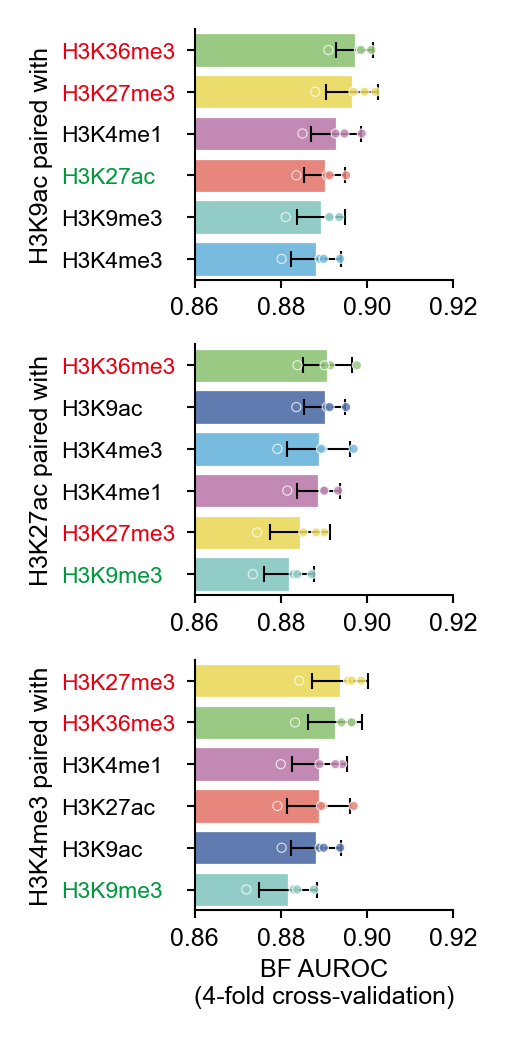

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

XTICKS = np.array([i / 100 for i in range(86, 93, 2)])
XTICKLABELS = [f"{x:.2f}" for x in XTICKS]

source_data_list = []

fig, ax = plt.subplots(3, 1, constrained_layout=True, figsize=(4/2.54, 8.5/2.54))

def _func(row, target_mark):
    marks = row['keep_marks'].split('_')
    marks.remove(target_mark)
    return marks[0]


# =========================================================
# PANEL 1: H3K9ac
# =========================================================
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data['auc'] = data['auc'] / 100
keep_mark = 'H3K9ac'

data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))].copy()
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark), axis=1)

sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
data = data[['keep_marks', 'fold', 'auc']].groupby(['keep_marks', 'fold'], as_index=False).agg('mean')

source_panel = data.copy()
source_panel['anchor_mark'] = keep_mark
source_panel = source_panel.rename(columns={'keep_marks': 'paired_mark'})
source_data_list.append(source_panel)

summary = data.groupby('keep_marks')['auc'].agg(['mean', 'std']).reindex(sorted_keep_marks)

y_pos = np.arange(len(sorted_keep_marks))

ax[0].barh(y_pos, summary['mean'], height=0.8, color=[COLOR_MAP.get(m, "gray") for m in sorted_keep_marks], alpha=1.0, linewidth=0.3, zorder=1)
ax[0].errorbar(summary['mean'], y_pos, xerr=summary['std'], fmt='none', ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5, zorder=3)
sns.stripplot(data=data, x="auc", y="keep_marks", order=sorted_keep_marks, palette=[COLOR_MAP[m] for m in sorted_keep_marks], jitter=0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor="white", ax=ax[0], legend=False, zorder=4)

ax[0].set_xlim(0.86, 0.92)
ax[0].set_xticks(XTICKS)
ax[0].set_xticklabels(XTICKLABELS)
ax[0].set_yticks(y_pos)
ax[0].set_yticklabels(sorted_keep_marks, fontsize=5.5, ha='left')
ax[0].tick_params(axis='y', pad=30)
ax[0].set_ylabel(f"{keep_mark} paired with", fontsize=6)
ax[0].set_xlabel('')
ax[0].legend().remove()

label_colors = ['#E60012', '#E60012', 'black', '#009A3E', 'black', 'black']
for label, color in zip(ax[0].get_yticklabels(), label_colors):
    label.set_color(color)


# =========================================================
# PANEL 2: H3K27ac
# =========================================================
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data['auc'] = data['auc'] / 100
keep_mark = 'H3K27ac'

data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))].copy()
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark), axis=1)

sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
data = data[['keep_marks', 'fold', 'auc']].groupby(['keep_marks', 'fold'], as_index=False).agg('mean')

source_panel = data.copy()
source_panel['anchor_mark'] = keep_mark
source_panel = source_panel.rename(columns={'keep_marks': 'paired_mark'})
source_data_list.append(source_panel)

summary = data.groupby('keep_marks')['auc'].agg(['mean', 'std']).reindex(sorted_keep_marks)

y_pos = np.arange(len(sorted_keep_marks))

ax[1].barh(y_pos, summary['mean'], height=0.8, color=[COLOR_MAP.get(m, "gray") for m in sorted_keep_marks], alpha=1.0, linewidth=0.3, zorder=1)
ax[1].errorbar(summary['mean'], y_pos, xerr=summary['std'], fmt='none', ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5, zorder=3)
sns.stripplot(data=data, x="auc", y="keep_marks", order=sorted_keep_marks, palette=[COLOR_MAP[m] for m in sorted_keep_marks], jitter=0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor="white", ax=ax[1], legend=False, zorder=4)

ax[1].set_xlim(0.86, 0.92)
ax[1].set_xticks(XTICKS)
ax[1].set_xticklabels(XTICKLABELS)
ax[1].set_yticks(y_pos)
ax[1].set_yticklabels(sorted_keep_marks, fontsize=5.5, ha='left')
ax[1].tick_params(axis='y', pad=30)
ax[1].set_ylabel(f"{keep_mark} paired with", fontsize=6)
ax[1].set_xlabel('')
ax[1].legend().remove()

label_colors = ['#E60012', 'black', 'black', 'black', '#E60012', '#009A3E']
for label, color in zip(ax[1].get_yticklabels(), label_colors):
    label.set_color(color)


# =========================================================
# PANEL 3: H3K4me3
# =========================================================
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data['auc'] = data['auc'] / 100
keep_mark = 'H3K4me3'

data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))].copy()
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark), axis=1)

sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
data = data[['keep_marks', 'fold', 'auc']].groupby(['keep_marks', 'fold'], as_index=False).agg('mean')

source_panel = data.copy()
source_panel['anchor_mark'] = keep_mark
source_panel = source_panel.rename(columns={'keep_marks': 'paired_mark'})
source_data_list.append(source_panel)

summary = data.groupby('keep_marks')['auc'].agg(['mean', 'std']).reindex(sorted_keep_marks)

y_pos = np.arange(len(sorted_keep_marks))

ax[2].barh(y_pos, summary['mean'], height=0.8, color=[COLOR_MAP.get(m, "gray") for m in sorted_keep_marks], alpha=1.0, linewidth=0.3, zorder=1)
ax[2].errorbar(summary['mean'], y_pos, xerr=summary['std'], fmt='none', ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5, zorder=3)
sns.stripplot(data=data, x="auc", y="keep_marks", order=sorted_keep_marks, palette=[COLOR_MAP[m] for m in sorted_keep_marks], jitter=0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor="white", ax=ax[2], legend=False, zorder=4)

ax[2].set_xlim(0.86, 0.92)
ax[2].set_xticks(XTICKS)
ax[2].set_xticklabels(XTICKLABELS)
ax[2].set_yticks(y_pos)
ax[2].set_yticklabels(sorted_keep_marks, fontsize=5.5, ha='left')
ax[2].tick_params(axis='y', pad=30)
ax[2].set_ylabel(f"{keep_mark} paired with", fontsize=6)
ax[2].set_xlabel('BF AUROC\n(4-fold cross-validation)', fontsize=6)
ax[2].legend().remove()

label_colors = ['#E60012', '#E60012', 'black', 'black', 'black', '#009A3E']
for label, color in zip(ax[2].get_yticklabels(), label_colors):
    label.set_color(color)


# =========================================================
# SOURCE DATA
# =========================================================
source_data = pd.concat(source_data_list, ignore_index=True)
source_data['target'] = 'BF'
source_data['cell_type_aggregation'] = 'Mean across H1, HepG2, and GM12878'
source_data = source_data[['anchor_mark', 'paired_mark', 'target', 'fold', 'auc', 'cell_type_aggregation']]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig3e.csv', index=False)

print(f'Source data saved to {source_dir}/fig3e.csv')

plt.savefig('extra/figures/v8/Figure3E.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Figure 3F

H3K36me3+H3K9ac: BF+ P = 9.730581540716017e-58, BF- P = 1.436640213308675e-237


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/3660202193.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['BF-', 'BF+'])


H3K27me3+H3K9ac: BF+ P = 0.7364314492540525, BF- P = 1.0918981097802997e-186


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/3660202193.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['BF-', 'BF+'])


H3K9me3+H3K9ac: BF+ P = 1.0932656686783905e-76, BF- P = 2.6869718037620973e-41


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/3660202193.py:193: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['BF-', 'BF+'])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Source data saved to scripts/figures/v8/source_data/fig3f.csv

Source data counts:
panel            bf_group  model_type 
H3K27me3+H3K9ac  BF+       paired_mark    7699
                           single_mark    7699
                 BF-       paired_mark    8166
                           single_mark    8166
H3K36me3+H3K9ac  BF+       paired_mark    7699
                           single_mark    7699
                 BF-       paired_mark    8166
                           single_mark    8166
H3K9me3+H3K9ac   BF+       paired_mark    7699
                           single_mark    7699
                 BF-       paired_mark    8166
                           single_mark    8166
dtype: int64


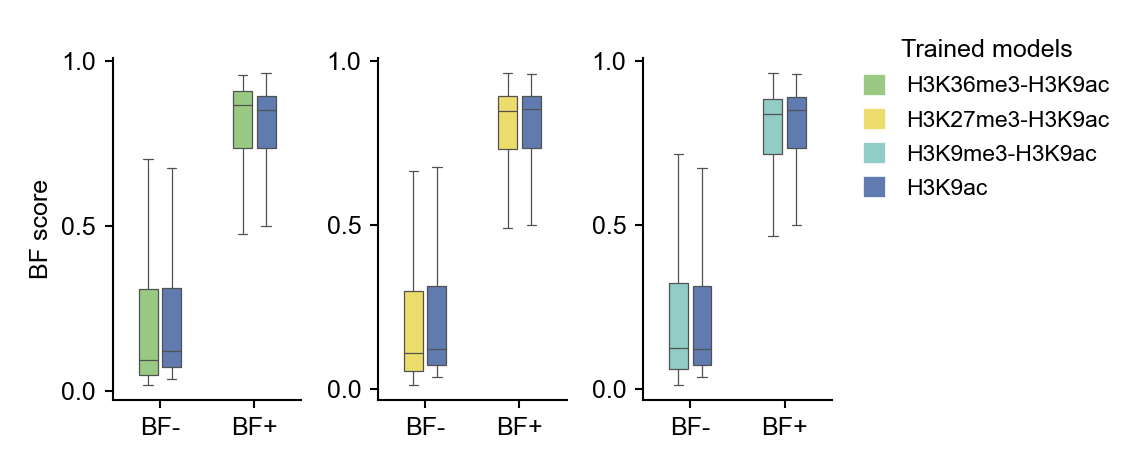

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon
import matplotlib.patches as mpatches

source_data_list = []

fig, ax = plt.subplots(1, 3, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))


# =========================================================
# PANEL 1: H3K36me3 + H3K9ac
# =========================================================
eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)

data = pd.concat([data1, data2], axis=0)

data = data[(data['mark1'] == mark1) & (data['mark2'] == mark2) & (data['eid'] == eid)].copy()
data = data[['gene_id', 'bf_label_label', 'bf_label_score', 'bf_label_pred', 'eid', 'fold', 'keep_marks']]

data2 = pd.read_csv('extra/results/single_mark_predictions_bs_bf.csv')
data2 = data2[(data2['keep_marks'] == mark2) & (data2['eid'] == eid)].copy()
data2 = data2[['gene_id', 'bf_label_label', 'bf_label_score', 'bf_label_pred', 'eid', 'fold', 'keep_marks']]

data = pd.concat([data, data2], axis=0, ignore_index=True)

# =========================================================
# SOURCE DATA: PANEL 1
# =========================================================
source_panel = data.copy()
source_panel['panel'] = f'{mark1}+{mark2}'
source_panel['comparison_mark'] = mark1
source_panel['reference_mark'] = mark2
source_panel['cell_type'] = source_panel['eid'].map(EIDS_TO_CELLTYPES)
source_panel['model_type'] = np.where(source_panel['keep_marks'] == mark2, 'single_mark', 'paired_mark')
source_panel['bf_group'] = source_panel['bf_label_label'].map({0: 'BF-', 1: 'BF+'})
source_data_list.append(source_panel)

# BF+
data_1 = data[(data['bf_label_label'] == 1) & (data['keep_marks'] == 'H3K9ac')]
data_2 = data[(data['bf_label_label'] == 1) & (data['keep_marks'] == f'{mark1}_H3K9ac')]
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'], data_2['bf_label_score'], alternative='two-sided')

# BF-
data_1 = data[(data['bf_label_label'] == 0) & (data['keep_marks'] == 'H3K9ac')]
data_2 = data[(data['bf_label_label'] == 0) & (data['keep_marks'] == f'{mark1}_H3K9ac')]
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'], data_2['bf_label_score'], alternative='two-sided')

print(f'{mark1}+{mark2}: BF+ P = {p_value_pos}, BF- P = {p_value_neg}')

palette = [COLOR_MAP['H3K36me3'], COLOR_MAP['H3K9ac']]
sns.boxplot(data=data, x='bf_label_label', y='bf_label_score', hue='keep_marks', fliersize=0, ax=ax[0], linewidth=0.3, palette=palette, saturation=1, width=0.5, gap=0.2)

ax[0].set_ylabel('BF score')
ax[0].set_yticks([i/10 for i in range(0, 11, 5)])
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].set_xticklabels(['BF-', 'BF+'])


# =========================================================
# PANEL 2: H3K27me3 + H3K9ac
# =========================================================
eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)

data = pd.concat([data1, data2], axis=0)

data = data[(data['mark1'] == mark1) & (data['mark2'] == mark2) & (data['eid'] == eid)].copy()
data = data[['gene_id', 'bf_label_label', 'bf_label_score', 'bf_label_pred', 'eid', 'fold', 'keep_marks']]

data2 = pd.read_csv('extra/results/single_mark_predictions_bs_bf.csv')
data2 = data2[(data2['keep_marks'] == mark2) & (data2['eid'] == eid)].copy()
data2 = data2[['gene_id', 'bf_label_label', 'bf_label_score', 'bf_label_pred', 'eid', 'fold', 'keep_marks']]

data = pd.concat([data, data2], axis=0, ignore_index=True)

# =========================================================
# SOURCE DATA: PANEL 2
# =========================================================
source_panel = data.copy()
source_panel['panel'] = f'{mark1}+{mark2}'
source_panel['comparison_mark'] = mark1
source_panel['reference_mark'] = mark2
source_panel['cell_type'] = source_panel['eid'].map(EIDS_TO_CELLTYPES)
source_panel['model_type'] = np.where(source_panel['keep_marks'] == mark2, 'single_mark', 'paired_mark')
source_panel['bf_group'] = source_panel['bf_label_label'].map({0: 'BF-', 1: 'BF+'})
source_data_list.append(source_panel)

# BF+
data_1 = data[(data['bf_label_label'] == 1) & (data['keep_marks'] == 'H3K9ac')]
data_2 = data[(data['bf_label_label'] == 1) & (data['keep_marks'] == f'{mark1}_H3K9ac')]
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'], data_2['bf_label_score'], alternative='two-sided')

# BF-
data_1 = data[(data['bf_label_label'] == 0) & (data['keep_marks'] == 'H3K9ac')]
data_2 = data[(data['bf_label_label'] == 0) & (data['keep_marks'] == f'{mark1}_H3K9ac')]
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'], data_2['bf_label_score'], alternative='two-sided')

print(f'{mark1}+{mark2}: BF+ P = {p_value_pos}, BF- P = {p_value_neg}')

palette = [COLOR_MAP['H3K27me3'], COLOR_MAP['H3K9ac']]
sns.boxplot(data=data, x='bf_label_label', y='bf_label_score', hue='keep_marks', fliersize=0, ax=ax[1], linewidth=0.3, palette=palette, saturation=1, width=0.5, gap=0.2)

ax[1].set_ylabel('', fontsize=6)
ax[1].set_yticks([i/10 for i in range(0, 11, 5)])
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels(['BF-', 'BF+'])


# =========================================================
# PANEL 3: H3K9me3 + H3K9ac
# =========================================================
eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)

data = pd.concat([data1, data2], axis=0)

data = data[(data['mark1'] == mark1) & (data['mark2'] == mark2) & (data['eid'] == eid)].copy()
data = data[['gene_id', 'bf_label_label', 'bf_label_score', 'bf_label_pred', 'eid', 'fold', 'keep_marks']]

data2 = pd.read_csv('extra/results/single_mark_predictions_bs_bf.csv')
data2 = data2[(data2['keep_marks'] == mark2) & (data2['eid'] == eid)].copy()
data2 = data2[['gene_id', 'bf_label_label', 'bf_label_score', 'bf_label_pred', 'eid', 'fold', 'keep_marks']]

data = pd.concat([data, data2], axis=0, ignore_index=True)

# =========================================================
# SOURCE DATA: PANEL 3
# =========================================================
source_panel = data.copy()
source_panel['panel'] = f'{mark1}+{mark2}'
source_panel['comparison_mark'] = mark1
source_panel['reference_mark'] = mark2
source_panel['cell_type'] = source_panel['eid'].map(EIDS_TO_CELLTYPES)
source_panel['model_type'] = np.where(source_panel['keep_marks'] == mark2, 'single_mark', 'paired_mark')
source_panel['bf_group'] = source_panel['bf_label_label'].map({0: 'BF-', 1: 'BF+'})
source_data_list.append(source_panel)

# BF+
data_1 = data[(data['bf_label_label'] == 1) & (data['keep_marks'] == 'H3K9ac')]
data_2 = data[(data['bf_label_label'] == 1) & (data['keep_marks'] == f'{mark1}_H3K9ac')]
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'], data_2['bf_label_score'], alternative='two-sided')

# BF-
data_1 = data[(data['bf_label_label'] == 0) & (data['keep_marks'] == 'H3K9ac')]
data_2 = data[(data['bf_label_label'] == 0) & (data['keep_marks'] == f'{mark1}_H3K9ac')]
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'], data_2['bf_label_score'], alternative='two-sided')

print(f'{mark1}+{mark2}: BF+ P = {p_value_pos}, BF- P = {p_value_neg}')

palette = [COLOR_MAP['H3K9me3'], COLOR_MAP['H3K9ac']]
sns.boxplot(data=data, x='bf_label_label', y='bf_label_score', hue='keep_marks', fliersize=0, ax=ax[2], linewidth=0.3, palette=palette, saturation=1, width=0.5, gap=0.2)

ax[2].set_ylabel('', fontsize=6)
ax[2].set_yticks([i/10 for i in range(0, 11, 5)])
ax[2].set_xlabel('')
ax[2].legend().remove()
ax[2].set_xticklabels(['BF-', 'BF+'])


# =========================================================
# LEGEND
# =========================================================
legend_patches = [
    mpatches.Patch(color=COLOR_MAP['H3K36me3'], label='H3K36me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K27me3'], label='H3K27me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K9me3'], label='H3K9me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K9ac'], label='H3K9ac'),
]

fig.legend(handles=legend_patches, title='Trained models', loc='upper left', bbox_to_anchor=(1, 1.05), title_fontsize=6, fontsize=5.5, edgecolor='none', handleheight=2/2.54, handlelength=2/2.54, handletextpad=1.0, labelspacing=1.5/2.54)


# =========================================================
# SOURCE DATA
# =========================================================
source_data = pd.concat(source_data_list, ignore_index=True)

source_columns = ['panel', 'comparison_mark', 'reference_mark', 'eid', 'cell_type', 'gene_id', 'fold', 'model_type', 'keep_marks', 'bf_label_label', 'bf_group', 'bf_label_score']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig3f.csv', index=False)

print(f'Source data saved to {source_dir}/fig3f.csv')

print('\nSource data counts:')
print(source_data.groupby(['panel', 'bf_group', 'model_type']).size())


# =========================================================
# SAVE FIGURE
# =========================================================
plt.savefig('extra/figures/v8/Figure3F.eps', format='eps', bbox_inches='tight')
plt.show()

In [15]:
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon


fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))


eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)

data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'],alternative='two-sided')


data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'],alternative='two-sided')

print(p_value_pos,p_value_neg)

palette = [COLOR_MAP['H3K36me3'],COLOR_MAP['H3K9ac']]
sns.boxplot(
    data=data,
    x='bf_label_label',
    y='bf_label_score',
    hue='keep_marks',
    fliersize=0,ax=ax[0],
    linewidth=0.3,
    palette=palette,
    saturation=1,
    width=0.5, 
    gap=0.2,
)
ax[0].set_ylabel(f'BF score')
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].set_xticklabels(["BF-","BF+"])



eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)



data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'],alternative='two-sided')


data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'],alternative='two-sided')

print(p_value_pos,p_value_neg)


palette = [COLOR_MAP['H3K27me3'],COLOR_MAP['H3K9ac']]
sns.boxplot(
    data=data,
    x='bf_label_label',
    y='bf_label_score',
    hue='keep_marks',
    fliersize=0,ax=ax[1],
    linewidth=0.3,
    palette=palette,
    saturation=1,
    width=0.5, 
    gap=0.2,
)

ax[1].set_ylabel(f'',fontsize=6)
ax[1].set_yticks([i/10 for i in range(0,11,5)])
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels(["BF-","BF+"])


eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)



data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_pos = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'],alternative='two-sided')


data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
# t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
t_stat, p_value_neg = wilcoxon(data_1['bf_label_score'],data_2['bf_label_score'],alternative='two-sided')

print(p_value_pos,p_value_neg)


palette = [COLOR_MAP['H3K9me3'],COLOR_MAP['H3K9ac']]
sns.boxplot(
    data=data,
    x='bf_label_label',
    y='bf_label_score',
    hue='keep_marks',
    fliersize=0,ax=ax[2],
    linewidth=0.3,
    palette=palette,
    saturation=1,
    width=0.5, 
    gap=0.2,
)

ax[2].set_ylabel(f'',fontsize=6)
ax[2].set_yticks([i/10 for i in range(0,11,5)])
ax[2].set_xlabel('')
ax[2].legend().remove()
ax[2].set_xticklabels(["BF-","BF+"])

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=COLOR_MAP['H3K36me3'], label='H3K36me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K27me3'], label='H3K27me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K9me3'], label='H3K9me3-H3K9ac'),
    mpatches.Patch(color=COLOR_MAP['H3K9ac'], label='H3K9ac'),

]

fig.legend(
    handles=legend_patches,
    title="Trained models",
    loc='upper left', 
    bbox_to_anchor=(1, 1.05),
    title_fontsize=6,
    fontsize=5.5,
    edgecolor='none',
    handleheight=2/2.54, 
    handlelength=2/2.54,
    handletextpad=1.0,
    labelspacing=1.5/2.54,
)  

# plt.savefig('extra/figures/v7/Figure3F.eps', format='eps', bbox_inches='tight')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'extra/results/keep_marks_predictions_bs_bf.csv'

# Figure 3G

Source data saved to scripts/figures/v8/source_data/fig3g.csv


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/2829634276.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_78918/2829634276.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


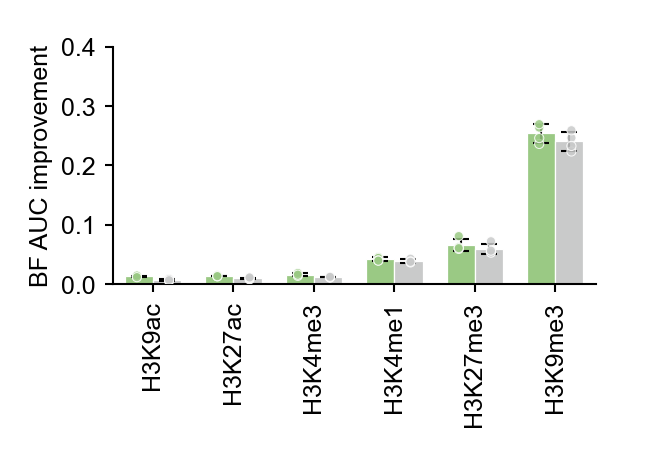

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target = 'bf_label'
keep_mark = 'H3K9ac'

# =========================================================
# LOAD DATA
# =========================================================
data1 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)

data2 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1], axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0], axis=1)

data = pd.concat([data1, data2], axis=0)
data = data[data['target'] == target].copy()

data2 = pd.read_csv(f'extra/results/one_feature_indicators_{target[:2]}_para.csv')
data2.columns = ['eid', 'mark2', 'fold', 'auc_single_mark2']

data = pd.merge(data, data2, on=['eid', 'mark2', 'fold'])
data['improvement'] = (data['auc'] - data['auc_single_mark2']) / 100

mark1 = 'H3K36me3'
data = data[data['mark2'] != mark1].copy()

data['is_mark1_combine'] = data.apply(lambda row: mark1 if row['mark1'] == mark1 else 'Average', axis=1)

# =========================================================
# AGGREGATION
# =========================================================
data = data[['fold', 'improvement', 'is_mark1_combine', 'mark2']].groupby(['fold', 'is_mark1_combine', 'mark2'], as_index=False).mean()

# =========================================================
# SOURCE DATA
# =========================================================
source_data = data.copy()
source_data['target'] = 'BF'
source_data['comparison_type'] = source_data['is_mark1_combine'].map({mark1: f'Paired with {mark1}', 'Average': 'Average of other paired-mark models'})
source_data['aggregation'] = 'Mean across cell types and applicable paired-mark models within each fold'

source_columns = ['target', 'mark2', 'is_mark1_combine', 'comparison_type', 'fold', 'improvement', 'aggregation']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig3g.csv', index=False)

print(f'Source data saved to {source_dir}/fig3g.csv')

# =========================================================
# FIGURE
# =========================================================
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(5/2.54, 3.5/2.54))

order = ['H3K9ac', 'H3K27ac', 'H3K4me3', 'H3K4me1', 'H3K27me3', 'H3K9me3']
hue_order = [mark1, 'Average']
palette = [COLOR_MAP[mark1], '#C9CACA']

# =========================================================
# MANUAL STATS
# =========================================================
summary = data.groupby(['mark2', 'is_mark1_combine'])['improvement'].agg(['mean', 'std']).reset_index()

x_pos = np.arange(len(order))
width = 0.35

# =========================================================
# MANUAL BAR + ERRORBAR
# =========================================================
for i, hue in enumerate(hue_order):
    sub = summary[summary['is_mark1_combine'] == hue]

    means = [sub[sub['mark2'] == m]['mean'].values[0] if m in sub['mark2'].values else 0 for m in order]
    stds = [sub[sub['mark2'] == m]['std'].values[0] if m in sub['mark2'].values else 0 for m in order]

    xpos = x_pos + i * width - width / 2

    ax.bar(xpos, means, width=width, color=palette[i], alpha=1.0, linewidth=0.3)

    ax.errorbar(xpos, means, yerr=stds, fmt='none', ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5)

# =========================================================
# STRIPPLOT
# =========================================================
sns.stripplot(data=data, x='mark2', y='improvement', hue='is_mark1_combine', order=order, hue_order=hue_order, palette=palette, dodge=True, jitter=0.0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor='white', legend=False, ax=ax)

# =========================================================
# STYLING
# =========================================================
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.legend().remove()

handles, labels = ax.get_legend_handles_labels()
labels = ['Average', mark1]

ax.set_xlabel('')
ax.set_ylabel('BF AUC improvement')
ax.set_yticks([i/100 for i in range(0, 41, 10)])

fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.98, 1.02), fontsize=6, ncol=1, edgecolor='none')

plt.savefig('extra/figures/v8/Figure3G.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
data = data[['fold','improvement','is_mark1_combine','mark2']].groupby(by=['fold','is_mark1_combine','mark2'],as_index=False).agg('mean')
# data = data[['keep_marks','fold','auc']].groupby(by=['keep_marks','fold'],as_index=False).agg('mean')

,fold,is_mark1_combine,mark2,improvement
0,0,Average,H3K27ac,0.008190
1,0,Average,H3K27me3,0.072267
2,0,Average,H3K4me1,0.042912
3,0,Average,H3K4me3,0.011389
4,0,Average,H3K9ac,0.005560
5,0,Average,H3K9me3,0.246386
6,0,H3K36me3,H3K27ac,0.013610
7,0,H3K36me3,H3K27me3,0.080975
8,0,H3K36me3,H3K4me1,0.045714
9,0,H3K36me3,H3K4me3,0.015567


# Supplementary

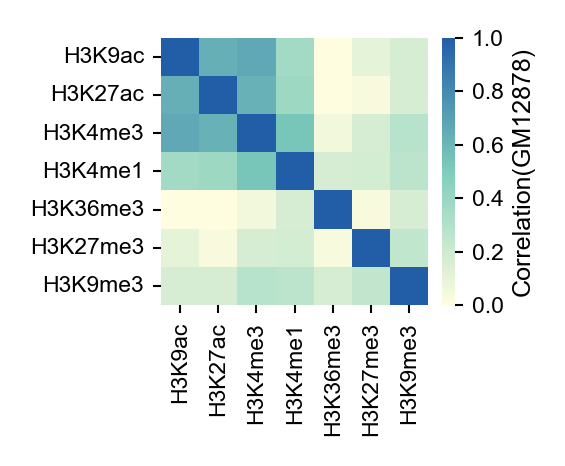

In [ ]:
eid = 'E116'
# correlation
correlation = np.loadtxt(f'extra/results/{eid}_hm_correlation.csv',delimiter=",")
# 选择第 0 个样本的行间相关性矩阵
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.5/2.54, 4.5/2.54))
ax = sns.heatmap(correlation,cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))
ax.set_xticklabels(MARKS,rotation=90)
ax.set_yticklabels(MARKS,rotation=360)
ax.set_aspect('equal')
ax.tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5)  # 设置colorbar刻度的粗细
cbar.set_label(f'Correlation({EIDS_TO_CELLTYPES[eid]})',fontsize=6)
plt.savefig(f'extra/figures/v6/Supplementary_Figure5C.eps', format='eps', bbox_inches='tight')
plt.show()


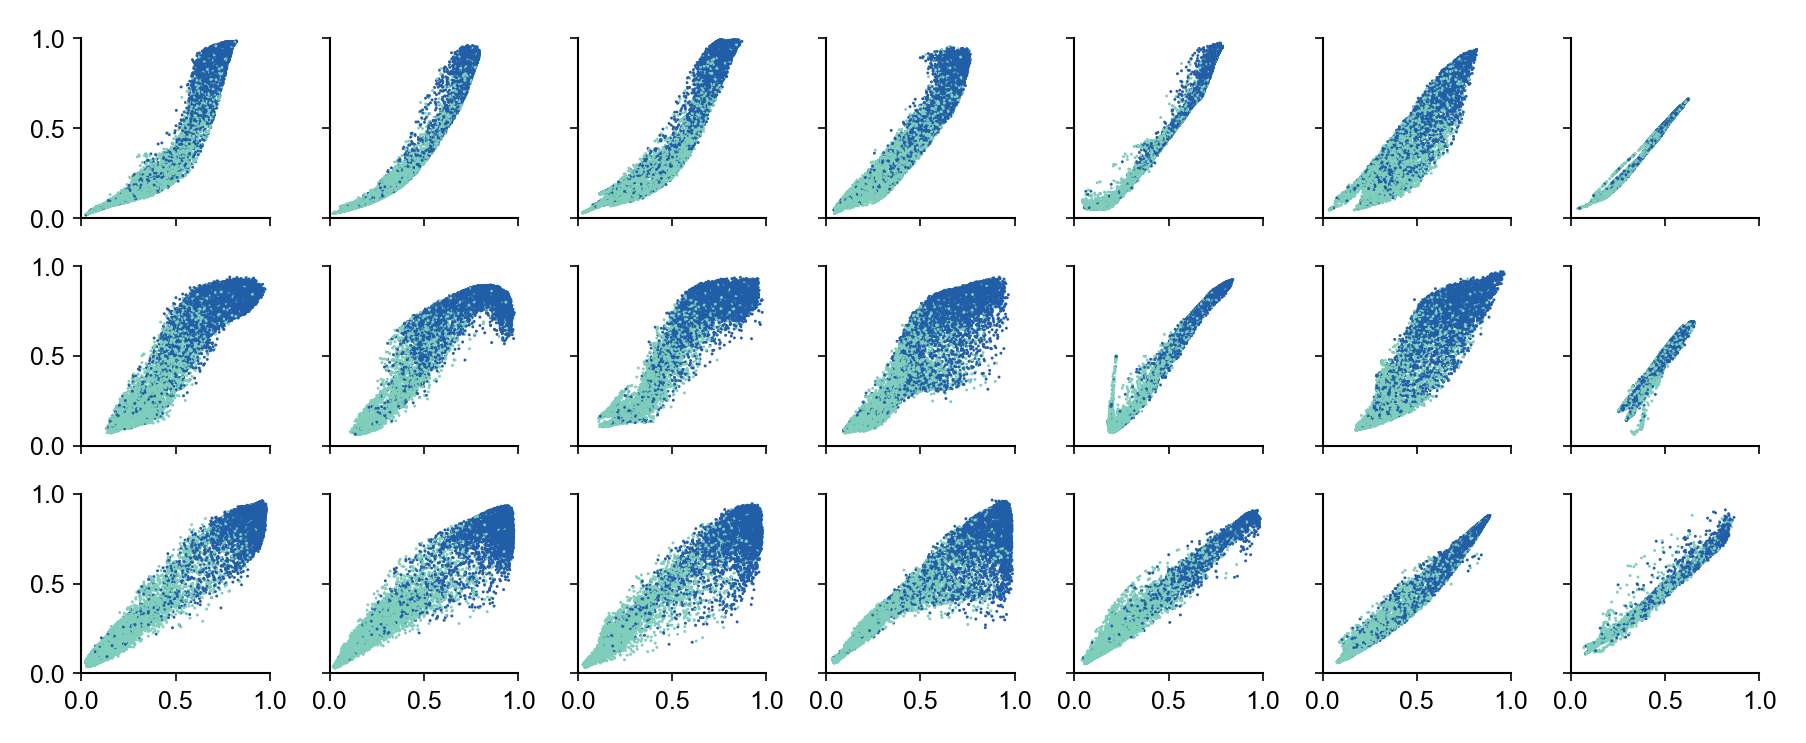

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

MARKS = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
EIDS = ['E003','E118','E116']  # H1, HepG2, GM12878

fig, axes = plt.subplots(3, 7, figsize=(15/2.54, 6/2.54), constrained_layout=True)
palette = ["#7FCDBB", "#225EA8"]

# 遍历三个细胞系
for row_idx, eid in enumerate(EIDS):
    for col_idx, keep_mark in enumerate(MARKS):
        ax = axes[row_idx, col_idx]
        data = pd.read_csv("extra/results/single_mark_predictions_bs_bf.csv")
        meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"

        data = data[(data['keep_marks'] == keep_mark) & (data['eid'] == eid)]
        meta = pd.read_csv(meta_path)[['gene_id','mean','mean_label','sc_exp_label','cv_label']]
        data = pd.merge(data, meta, how='inner', on='gene_id')

        sns.scatterplot(
            x=data['bs_label_score'], y=data['bf_label_score'],
            hue=data['mean_label'], palette=palette, s=0.5,
            legend=False, ax=ax, linewidth=0,
            rasterized = True,
            
        )

        ax.set_title('', fontsize=6, pad=2)
        # ax.set_xlabel('' if row_idx < 2 else f'BS score ({EIDS_TO_CELLTYPES[eid]})', fontsize=6)
        # ax.set_ylabel('' if col_idx > 0 else f'BF score ({EIDS_TO_CELLTYPES[eid]})', fontsize=6)
        ax.set_xlabel('' )
        ax.set_ylabel('')
        ax.set_xticks([0, 0.5, 1.0])
        ax.set_yticks([0, 0.5, 1.0])
        if row_idx < 2:
            ax.set_xticklabels(['', '', ''], )
        if col_idx > 0:
            ax.set_yticklabels(['', '', ''], )

        ax.tick_params(axis='both', width=0.4, labelsize=6)
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)

    # 每一行添加标题
    # axes[row_idx, 0].text(-1.5, 0.5, f"{EIDS_TO_CELLTYPES[eid]} cells", fontsize=7, fontweight='bold',
    #                        rotation=90, va='center', ha='center', transform=axes[row_idx, 0].transAxes)

# 添加 legend
legend_patches = [
    mlines.Line2D([], [], marker='o', linestyle='None', color="#225EA8", markersize=2, label="High expression"),
    mlines.Line2D([], [], marker='o', linestyle='None', color="#7FCDBB", markersize=2, label="Low expression"),
]
# fig.legend(handles=legend_patches, title="Expression", loc="upper right",
#            bbox_to_anchor=(1.05, 1), title_fontsize=6, fontsize=5, frameon=False)

# 保存与展示
plt.savefig('extra/figures/v7/Supplementary_Figure7.eps', format='eps',bbox_inches='tight', dpi=600)
plt.show()

# Supplementary Figure 5D

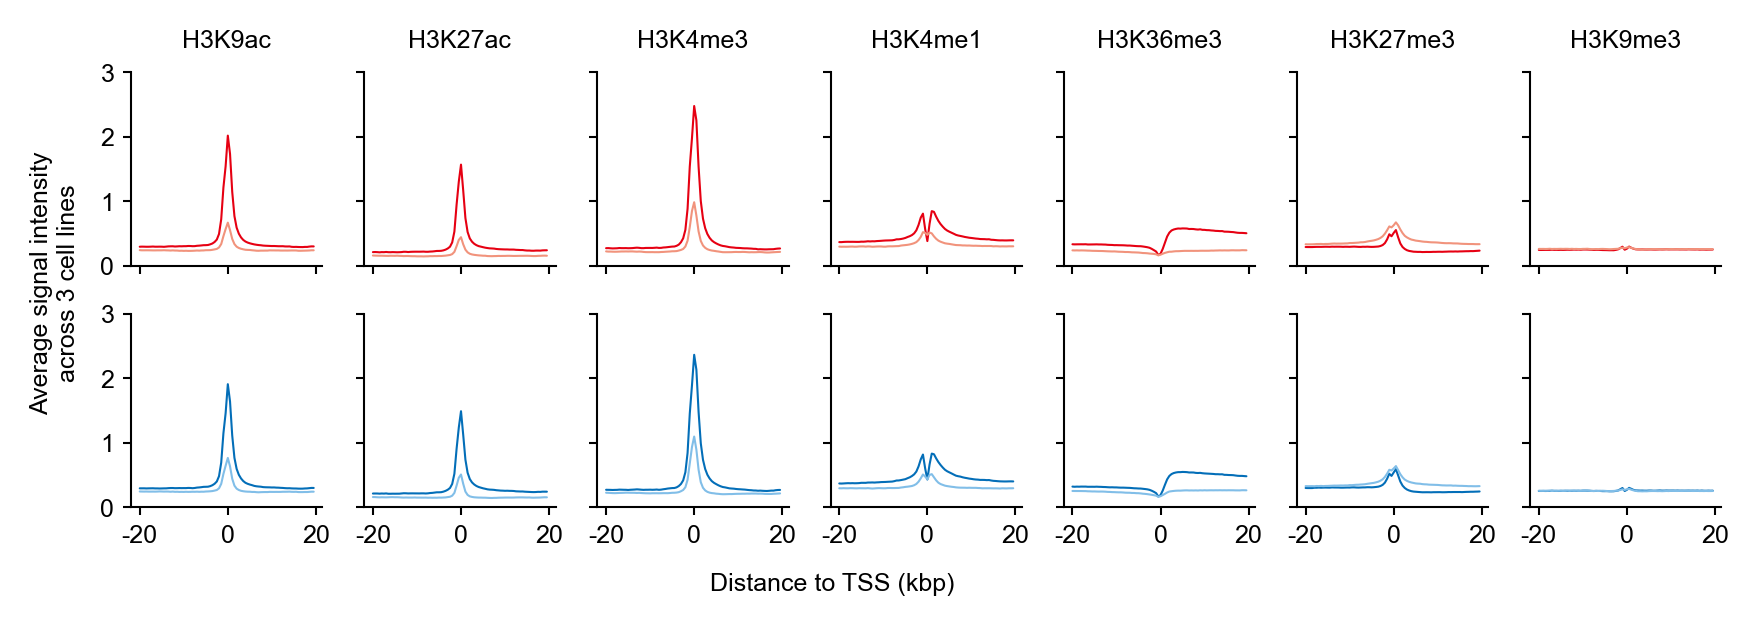

In [5]:

fig, ax = plt.subplots(2, 7, constrained_layout=True, figsize=(14/2.54, 5/2.54))
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = ['H3K9ac', 'H3K27ac','H3K4me3','H3K4me1' ,'H3K36me3','H3K27me3','H3K9me3']

eid = 'E003'
high_marks_E003 = np.load(f"extra/results/{eid}_bf_para_highmarks.npy")
low_marks_E003 = np.load(f"extra/results/{eid}_bf_para_lowmarks.npy")

eid = 'E116'
high_marks_E116 = np.load(f"extra/results/{eid}_bf_para_highmarks.npy")
low_marks_E116 = np.load(f"extra/results/{eid}_bf_para_lowmarks.npy")

eid = 'E118'
high_marks_E118 = np.load(f"extra/results/{eid}_bf_para_highmarks.npy")
low_marks_E118 = np.load(f"extra/results/{eid}_bf_para_lowmarks.npy")

high_marks = (high_marks_E003 + high_marks_E116 + high_marks_E118) / 3
low_marks = (low_marks_E003 + low_marks_E116 + low_marks_E118) / 3

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='#E60012',  ax=ax[0, idx],linewidth=0.5)
    sns.lineplot(low_marks[_idx], color='#F1937C',  ax=ax[0, idx],linewidth=0.5)
    # Set the y-axis ticks
    ax[0, idx % 7].set_yticks([i * 0.1 for i in range(0, 31, 10)])
    ax[0, idx % 7].set_xticks([i for i in range(0, 81, 40)],labels=[int((i-40)/2) for i in range(0, 81, 40)])
    if idx == 0:
        ax[0, idx % 7].tick_params(axis='both', width=0.5,labelbottom=False)
    else:
        ax[0, idx % 7].tick_params(axis='both', width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[0, idx % 7].set_title(mark, )
    ax[0, idx % 7].set_ylim(ymax=3)
    # Set the xlabel for each subplot

lines = ax[0,0].get_lines()

handles0 = [lines[0], lines[1]]
labels0  = ["$BF^+$","$BF^-$"]

eid = 'E003'
high_marks_E003 = np.load(f"extra/results/{eid}_bs_para_highmarks.npy")
low_marks_E003 = np.load(f"extra/results/{eid}_bs_para_lowmarks.npy")

eid = 'E116'
high_marks_E116 = np.load(f"extra/results/{eid}_bs_para_highmarks.npy")
low_marks_E116 = np.load(f"extra/results/{eid}_bs_para_lowmarks.npy")

eid = 'E118'
high_marks_E118 = np.load(f"extra/results/{eid}_bs_para_highmarks.npy")
low_marks_E118 = np.load(f"extra/results/{eid}_bs_para_lowmarks.npy")

high_marks = (high_marks_E003 + high_marks_E116 + high_marks_E118) / 3
low_marks = (low_marks_E003 + low_marks_E116 + low_marks_E118) / 3

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='#036EB8',  ax=ax[1, idx],linewidth=0.5)
    sns.lineplot(low_marks[_idx], color='#81BEE8',  ax=ax[1, idx],linewidth=0.5)
    # Set the y-axis ticks
    ax[1, idx % 7].set_yticks([i * 0.1 for i in range(0, 31, 10)])
    ax[1, idx % 7].set_xticks([i for i in range(0, 81, 40)],labels=[int((i-40)/2) for i in range(0, 81, 40)])
    if idx == 0:
        ax[1, idx % 7].tick_params(axis='both', width=0.5,labelbottom=True)
    else:
        ax[1, idx % 7].tick_params(axis='both', width=0.5,labelbottom=True,labelleft=False)

    ax[1, idx % 7].set_ylim(ymax=3)
    # Set the xlabel for each subplot

lines = ax[1,0].get_lines()

handles1 = [lines[0], lines[1]]
labels1 = ["$BS^+$","$BS^-$"]

ax[0,0].set_ylabel('',fontsize=5)
ax[1,0].set_ylabel('',fontsize=5)

fig.supxlabel("Distance to TSS (kbp)",fontsize=6,x=0.45)
fig.supylabel(f"Average signal intensity\nacross 3 cell lines",fontsize=6,x=-0.02 ,y=0.55,ha='center')
# Adjust layout to ensure everything fits


plt.savefig('extra/figures/v7/Supplementary_Figure5D.eps', format='eps', bbox_inches='tight')

plt.show()


# Supplementary Figure6

In [13]:
data = pd.read_csv("extra/results/single_mark_predictions_bs_bf.csv")
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"
data = data[(data['keep_marks'] == keep_mark) & (data['eid'] == eid)]
meta = pd.read_csv(meta_path)[['gene_id','mean','mean_label','sc_exp_label','cv_label']]
data = pd.merge(data, meta, how='inner', on='gene_id')
data


,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,keep_marks,eid,mean,mean_label,sc_exp_label,cv_label
0,ENSG00000132470,1,0.210021,0,0,0.230997,0,0,H3K9me3,E116,6.020660e-03,0,0,1
1,ENSG00000197446,0,0.118147,0,0,0.147839,0,0,H3K9me3,E116,9.999990e-07,0,0,0
2,ENSG00000136110,0,0.634813,1,0,0.575780,1,0,H3K9me3,E116,5.179073e-04,0,0,1
3,ENSG00000105576,1,0.515465,1,1,0.485377,0,0,H3K9me3,E116,1.847274e-01,1,1,1
4,ENSG00000136872,0,0.646328,1,0,0.582475,1,0,H3K9me3,E116,5.179179e-04,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15860,ENSG00000243543,0,0.618143,1,0,0.574040,1,3,H3K9me3,E116,9.999990e-07,0,0,0
15861,ENSG00000116031,0,0.538488,1,0,0.481368,0,3,H3K9me3,E116,9.999990e-07,0,0,0
15862,ENSG00000099377,1,0.328417,0,0,0.349419,0,3,H3K9me3,E116,6.456735e-03,0,0,1
15863,ENSG00000087263,1,0.631745,1,1,0.580727,1,3,H3K9me3,E116,3.541246e-01,1,1,0


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/430444631.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels, fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/430444631.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels, fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/430444631.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels, fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/430444631.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(

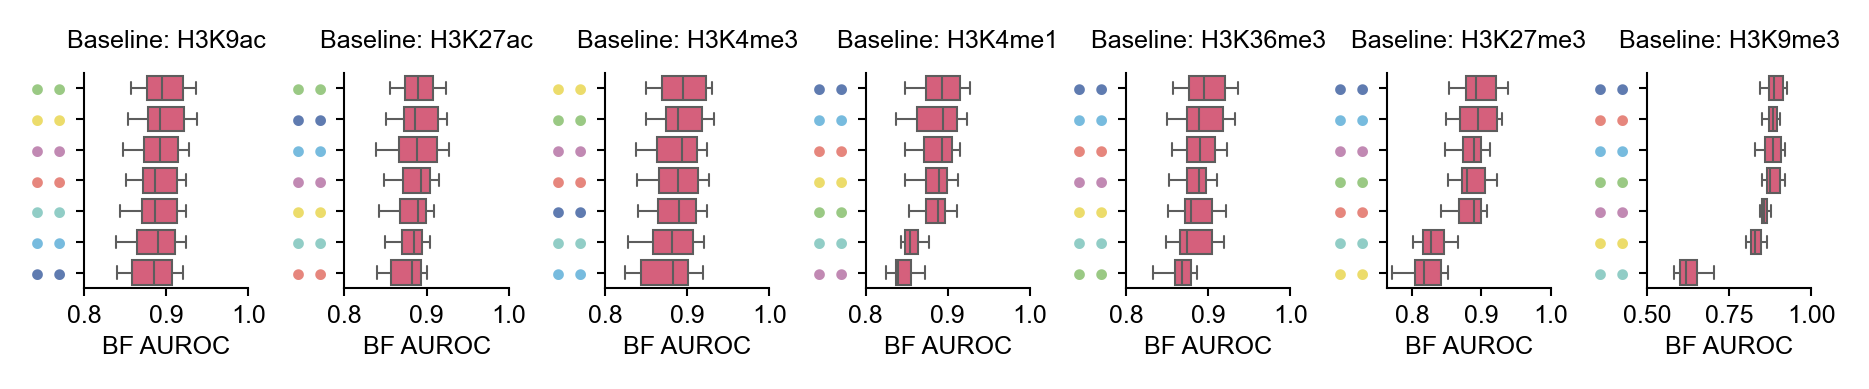

In [14]:
target = 'bf'
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
palette = ['#E94C72','#036EB8']
fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(15.5/2.54, 3/2.54))
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]

    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark), axis=1)

    data2 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']

    data = pd.concat([data1, data2], axis=0)
    data['auc'] = data['auc'] / 100

    # 排序 & 调色
    sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
    # palette = [COLOR_MAP[mark] for mark in sorted_keep_marks]

    ax_sub = ax[_idx]
    sns.boxplot(
        data=data, y='keep_marks', x='auc',
        fliersize=0, linewidth=0.5,
        order=sorted_keep_marks, color=palette[0], ax=ax_sub, orient='h'
    )

    ax_sub.set_title(f'Baseline: {keep_mark}')
    ax_sub.set_ylabel('')
    ax_sub.set_xlabel(f'{target.upper()} AUROC')

    xticks = [0.8, 0.9, 1.0]
    xticklabels = [f'{x:.1f}' for x in xticks]
    ax_sub.set_xticks(xticks, labels=xticklabels)

    
    if keep_mark == 'H3K9me3':
       xticks = [0.5, 0.75, 1.0]
       xticklabels = [f'{x:.2f}' for x in xticks]
       ax_sub.set_xticks(xticks, labels=xticklabels)

    # --- 替换 yticklabels 为彩色竖排圆点 ---
    labels = ax_sub.get_yticklabels()
    for lbl, mark in zip(labels, sorted_keep_marks):
        lbl.set_text("● ●")          # 用圆点符号
        lbl.set_color(COLOR_MAP[mark])  # 上色
    ax_sub.set_yticklabels(labels, fontsize=6)

plt.savefig(
    'extra/figures/v7/Supplementary_Figure6A.eps',
    format='eps', bbox_inches='tight'
)
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/1299197964.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels,fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/1299197964.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels,fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/1299197964.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels(labels,fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_74482/1299197964.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_sub.set_yticklabels

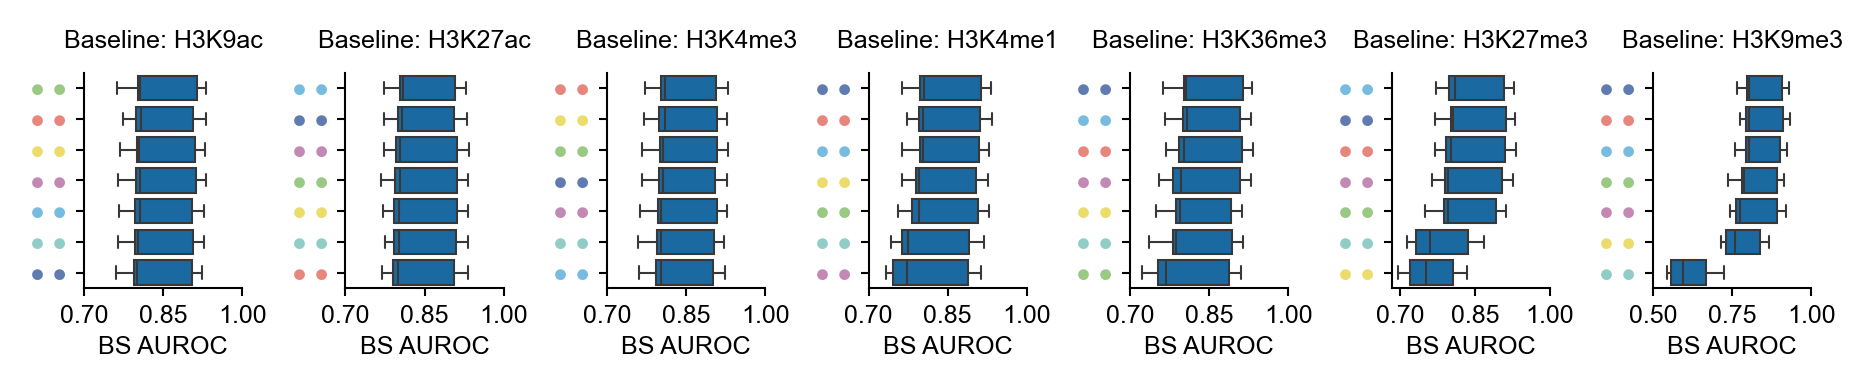

In [15]:
target = 'bs'
MARKS =  [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
palette = ['#E94C72','#036EB8']
fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(15.5/2.54, 3/2.54))
for _idx, keep_mark in enumerate(MARKS):
    data1 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
    data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) & (data1['target'] == f'{target}_label')][['eid','keep_marks','fold','auc']]

    def _func(row, target_mark):
        marks = row['keep_marks'].split('_')
        marks.remove(target_mark)
        return marks[0]

    data1['keep_marks'] = data1.apply(lambda row: _func(row, keep_mark), axis=1)

    data2 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
    data2 = data2[(data2['keep_mark'] == keep_mark)]
    data2.columns = ['eid','keep_marks','fold','auc']

    data = pd.concat([data1, data2], axis=0)
    data['auc'] = data['auc'] / 100

    # 排序 & 调色
    sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index

    ax_sub = ax[_idx]
    sns.boxplot(
        data=data, y='keep_marks', x='auc',
        fliersize=0, linewidth=0.5,
        order=sorted_keep_marks, color=palette[1], ax=ax_sub, orient='h'
    )

    ax_sub.set_title(f'Baseline: {keep_mark}')
    ax_sub.set_ylabel('')
    ax_sub.set_xlabel(f'{target.upper()} AUROC')


    xticks = [0.7, 0.85, 1.0]
    xticklabels = [f'{x:.2f}' for x in xticks]
    ax_sub.set_xticks(xticks, labels=xticklabels)

    
    if keep_mark == 'H3K9me3':
       xticks = [0.5, 0.75, 1.0]
       xticklabels = [f'{x:.2f}' for x in xticks]
       ax_sub.set_xticks(xticks, labels=xticklabels)

    # --- 替换 yticklabels 为彩色竖排圆点 ---
    labels = ax_sub.get_yticklabels()
    for lbl, mark in zip(labels, sorted_keep_marks):
        lbl.set_text("● ●")          # 用圆点符号
        lbl.set_color(COLOR_MAP[mark])  # 上色
    ax_sub.set_yticklabels(labels,fontsize=6)

plt.savefig(
    'extra/figures/v7/Supplementary_Figure6B.eps',
    format='eps', bbox_inches='tight'
)
plt.show()

## paired gain 

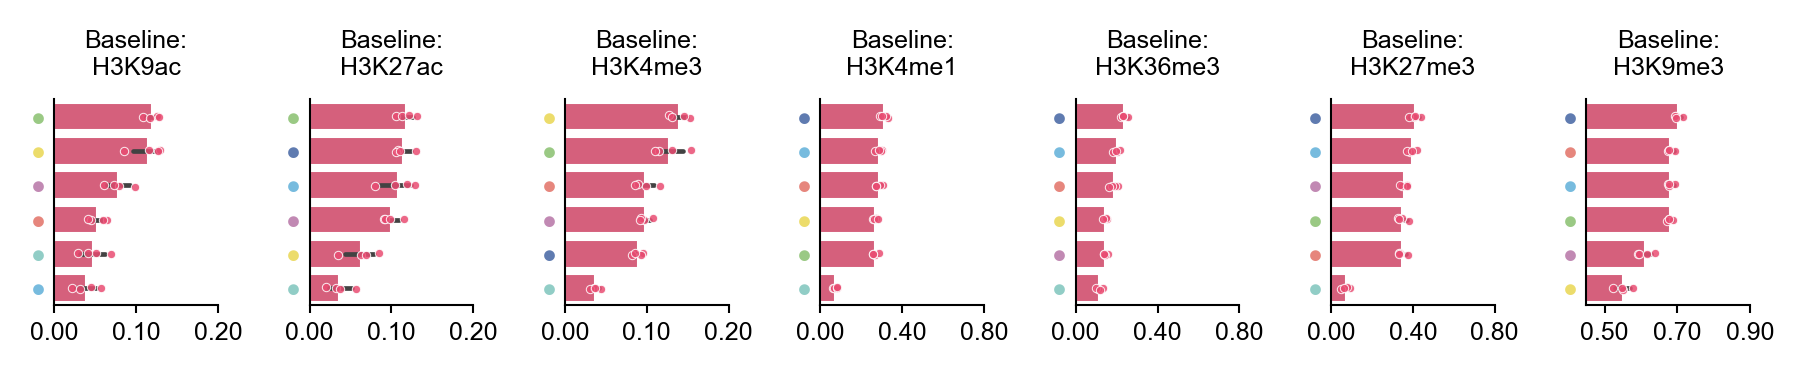

In [90]:

# ============================================================
# Config
# ============================================================
TARGET = "bf"   # "bf" or "bs"

MARKS = [
    "H3K9ac",
    "H3K27ac",
    "H3K4me3",
    "H3K4me1",
    "H3K36me3",
    "H3K27me3",
    "H3K9me3",
]


PAIRWISE_RESULT_FILE = "extra/results/bs_bf_para_keep_marks_indicators.csv"
SINGLE_RESULT_FILE = f"extra/results/one_feature_indicators_{TARGET}_para.csv"

SAVE_FIG = False
OUT_DIR = "extra/figures/marginal_gain_analysis"
# os.makedirs(OUT_DIR, exist_ok=True)
palette = ['#E94C72','#036EB8']

# ============================================================
# Utilities
# ============================================================
def parse_two_marks(keep_marks):
    marks = str(keep_marks).split("_")
    marks = [m for m in marks if m in MARKS]
    if len(marks) != 2:
        return None
    return marks


def safe_divide(numerator, denominator, eps=1e-8):
    return numerator / np.maximum(denominator, eps)


# ============================================================
# 1. Load single-mark results
# ============================================================
single_df = pd.read_csv(SINGLE_RESULT_FILE).copy()

single_df = single_df.rename(
    columns={
        "keep_mark": "mark",
        "auc": "single_auc",
    }
)

single_df = single_df[["eid", "mark", "fold", "single_auc"]].copy()
single_df = single_df[single_df["mark"].isin(MARKS)].copy()
single_df["single_auc"] = single_df["single_auc"] / 100.0


# ============================================================
# 2. Load pairwise results
# ============================================================
pair_df = pd.read_csv(PAIRWISE_RESULT_FILE).copy()
pair_df = pair_df[pair_df["target"] == f"{TARGET}_label"].copy()

pair_df["parsed_marks"] = pair_df["keep_marks"].apply(parse_two_marks)
pair_df = pair_df[pair_df["parsed_marks"].notna()].copy()

pair_df["mark_A"] = pair_df["parsed_marks"].apply(lambda x: x[0])
pair_df["mark_B"] = pair_df["parsed_marks"].apply(lambda x: x[1])
pair_df["pair_auc"] = pair_df["auc"] / 100.0

pair_df = pair_df[
    ["eid", "fold", "keep_marks", "mark_A", "mark_B", "pair_auc"]
].copy()


# ============================================================
# 3. Build directional table:
#    For each pair A+B, generate A -> A+B and B -> A+B
# ============================================================
records = []

for _, row in pair_df.iterrows():
    eid = row["eid"]
    fold = row["fold"]
    mark_A = row["mark_A"]
    mark_B = row["mark_B"]
    pair_auc = row["pair_auc"]
    keep_marks = row["keep_marks"]

    records.append(
        {
            "eid": eid,
            "fold": fold,
            "keep_marks": keep_marks,
            "baseline_mark": mark_A,
            "added_mark": mark_B,
            "pair_auc": pair_auc,
        }
    )

    records.append(
        {
            "eid": eid,
            "fold": fold,
            "keep_marks": keep_marks,
            "baseline_mark": mark_B,
            "added_mark": mark_A,
            "pair_auc": pair_auc,
        }
    )

delta_df = pd.DataFrame(records)


# ============================================================
# 4. Merge single-mark AUCs
# ============================================================
baseline_single = single_df.rename(
    columns={
        "mark": "baseline_mark",
        "single_auc": "baseline_auc",
    }
)

added_single = single_df.rename(
    columns={
        "mark": "added_mark",
        "single_auc": "added_auc",
    }
)

delta_df = delta_df.merge(
    baseline_single,
    on=["eid", "fold", "baseline_mark"],
    how="left",
)

delta_df = delta_df.merge(
    added_single,
    on=["eid", "fold", "added_mark"],
    how="left",
)

if delta_df["baseline_auc"].isna().any():
    raise ValueError("Some baseline single-mark AUC values are missing.")

if delta_df["added_auc"].isna().any():
    raise ValueError("Some added-mark single AUC values are missing.")


# ============================================================
# 5. Compute marginal gain metrics
# ============================================================
# Absolute marginal gain:
# AUC(A+B) - AUC(A)
delta_df["delta_auc"] = delta_df["pair_auc"] - delta_df["baseline_auc"]

# Normalized marginal gain:
# [AUC(A+B) - AUC(A)] / [1 - AUC(A)]
delta_df["normalized_marginal_gain"] = safe_divide(
    delta_df["delta_auc"],
    1.0 - delta_df["baseline_auc"],
)

# # Gain over the better single-mark model:
# # AUC(A+B) - max(AUC(A), AUC(B))
delta_df["best_single_auc"] = delta_df[["baseline_auc", "added_auc"]].max(axis=1)
delta_df["gain_over_best_single"] = (
    delta_df["pair_auc"] - delta_df["best_single_auc"]
)

delta_df["pair_name"] = delta_df.apply(
    lambda r: " + ".join(sorted([r["baseline_mark"], r["added_mark"]])),
    axis=1,
)

# ============================================================
# 7. Plot normalized marginal gain by baseline mark
#    Replace y-axis labels with colored circles
# ============================================================
fig, axes = plt.subplots(
    1,
    len(MARKS),
    figsize=(15.5 / 2.54, 3.4 / 2.54),
)

for idx, baseline_mark in enumerate(MARKS):
    ax = axes[idx]
    sub = delta_df[delta_df["baseline_mark"] == baseline_mark].copy()
    sub = sub[['added_mark','normalized_marginal_gain','fold',]].groupby(by=['added_mark','fold'],as_index=False).agg('mean')

    order = (
        sub.groupby("added_mark")["normalized_marginal_gain"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # sns.boxplot(
    #     data=sub,
    #     y="added_mark",
    #     x="normalized_marginal_gain",
    #     order=order,
    #     fliersize=0,
    #     linewidth=0.5,
    #     color="#4C78A8",
    #     ax=ax,
    #     orient="h",
    # )
    sns.barplot(
        data=sub,
        y="added_mark",
        x="normalized_marginal_gain",
        order=order,
        linewidth=0.5,
        color=palette[0],
        ax=ax,
        orient="h",
    )
    sns.stripplot(
        data=sub,
        x="normalized_marginal_gain",
        y="added_mark",
        order=order,
        color=palette[0],
        dodge=True,
        jitter=0.04,
        size=2,
        alpha=0.85,
        linewidth=0.25,
        edgecolor="white",
        ax=ax,
        legend=False,
    )

    # ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(f"Baseline:\n{baseline_mark}", )
    ax.set_xlabel("", )
    ax.set_ylabel("")
    ax.tick_params(axis="x", )
    ax.tick_params(axis="y", length=0)

    # --------------------------------------------------------
    # Replace y-axis mark names with colored circles
    # --------------------------------------------------------
    y_positions = np.arange(len(order))
    circle_labels = ["●" for _ in order]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(circle_labels, )

    for tick_label, mark in zip(ax.get_yticklabels(), order):
        tick_label.set_color(COLOR_MAP.get(mark, "black"))

    # Optional: make x-axis range comparable across panels
    # 根据你的实际结果可以调整
    ax.set_xlim(0, 0.2)
    xticks = [0, 0.1, 0.2]
    xticklabels = [f'{x:.2f}' for x in xticks]
    ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K4me1':
        ax.set_xlim(0, 0.8)
        xticks = [0, 0.4, 0.8]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K4me3':
        xticks = [0, 0.1, 0.2]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K36me3':
        ax.set_xlim(0, 0.8)
        xticks = [0, 0.4, 0.8]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K27me3':
        ax.set_xlim(0, 0.8)
        xticks = [0, 0.4, 0.8]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K9me3':
        ax.set_xlim(0.45, 0.9)
        xticks = [0.5, 0.7, 0.9]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

plt.tight_layout()
plt.savefig(
    'extra/figures/v8/Supplementary_Figure6C.pdf',
    format='pdf', bbox_inches='tight'
)
plt.show()

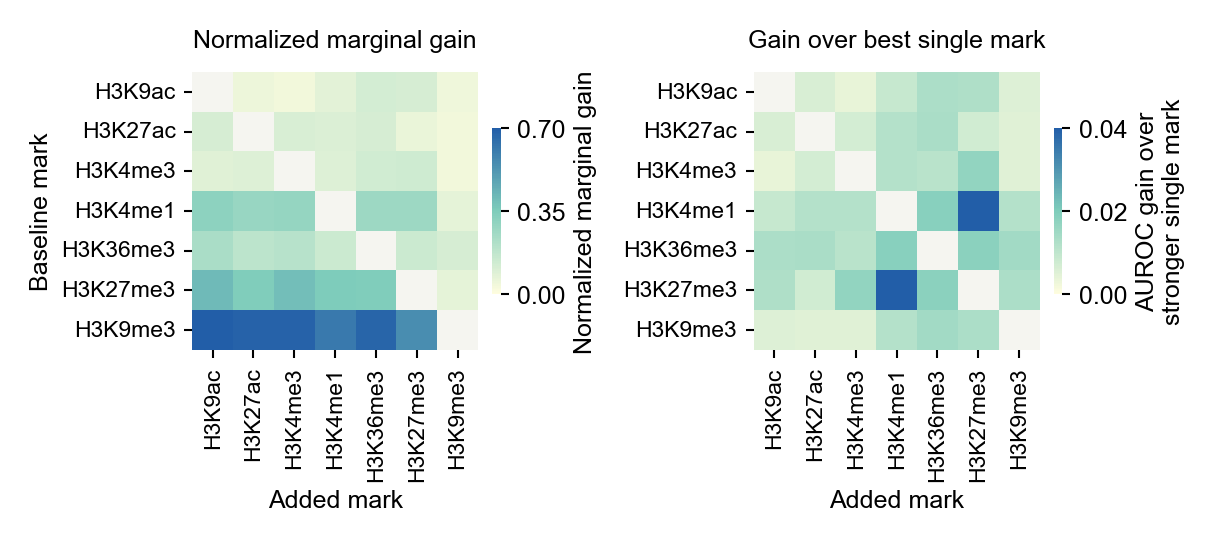

In [91]:
# ============================================================
# 7. Plot heatmaps from delta_df
#    Row: baseline mark
#    Column: added mark
#    Color: mean gain
# ============================================================

# ------------------------------------------------------------
# 7.1 Summarize directional marginal gain
# ------------------------------------------------------------
heatmap_df = (
    delta_df
    .groupby(["baseline_mark", "added_mark"], as_index=False)
    .agg(
        mean_normalized_marginal_gain=("normalized_marginal_gain", "mean"),
        mean_gain_over_best_single=("gain_over_best_single", "mean"),
        mean_delta_auc=("delta_auc", "mean"),
        mean_pair_auc=("pair_auc", "mean"),
        mean_baseline_auc=("baseline_auc", "mean"),
        mean_added_auc=("added_auc", "mean"),
        n=("normalized_marginal_gain", "size"),
    )
)

# ------------------------------------------------------------
# 7.2 Build heatmap matrices
# ------------------------------------------------------------
normalized_gain_mat = (
    heatmap_df
    .pivot(
        index="baseline_mark",
        columns="added_mark",
        values="mean_normalized_marginal_gain",
    )
    .reindex(index=MARKS, columns=MARKS)
)

gain_best_mat = (
    heatmap_df
    .pivot(
        index="baseline_mark",
        columns="added_mark",
        values="mean_gain_over_best_single",
    )
    .reindex(index=MARKS, columns=MARKS)
)

# Set diagonal as NA
for mark in MARKS:
    normalized_gain_mat.loc[mark, mark] = np.nan
    gain_best_mat.loc[mark, mark] = np.nan


# ------------------------------------------------------------
# 7.3 Helper for colored tick labels
# ------------------------------------------------------------
def color_mark_ticklabels(ax):
    for label in ax.get_xticklabels():
        mark = label.get_text()
        label.set_color(COLOR_MAP.get(mark, "black"))

    for label in ax.get_yticklabels():
        mark = label.get_text()
        label.set_color(COLOR_MAP.get(mark, "black"))


# ------------------------------------------------------------
# 7.4 Plot heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, constrained_layout=True, figsize=(10/2.54, 4.3/2.54))

# -------------------------
# Heatmap 1:
# normalized marginal gain
# -------------------------
ax = axes[0]


COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
sns.heatmap(normalized_gain_mat,
            cbar_kws={"shrink": 0.6, "fraction": 0.05,"ticks": [0, 0.35, 0.7],"label":"Normalized marginal gain"},
            vmin=0, vmax=0.7,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=ax)

ax.set_facecolor("#F5F5F0")
ax.set_title("Normalized marginal gain")
ax.set_xlabel("Added mark")
ax.set_ylabel("Baseline mark")
ax.set_xticklabels(MARKS,rotation=90,fontsize=5.5)
ax.set_yticklabels(MARKS,rotation=360, fontsize=5.5)
# color_mark_ticklabels(ax)


# -------------------------
# Heatmap 2:
# gain over best single mark
# -------------------------
ax = axes[1]

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
sns.heatmap(gain_best_mat,cbar_kws={"shrink": 0.6, "fraction": 0.05,"ticks": [0, 0.02, 0.04],"label": "AUROC gain over\nstronger single mark",},vmin=0, vmax=0.04,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=ax)


ax.set_facecolor("#F5F5F0")
ax.set_title(r"Gain over best single mark")
ax.set_xlabel("Added mark")
ax.set_ylabel("")

ax.set_xticklabels(MARKS,rotation=90,fontsize=5.5)
ax.set_yticklabels(MARKS,rotation=360, fontsize=5.5)
# color_mark_ticklabels(ax)


# ------------------------------------------------------------
# 7.5 Save and show
# ------------------------------------------------------------
# plt.tight_layout()

plt.savefig(
    "extra/figures/v8/Supplementary_Figure6C_heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
)


plt.show()

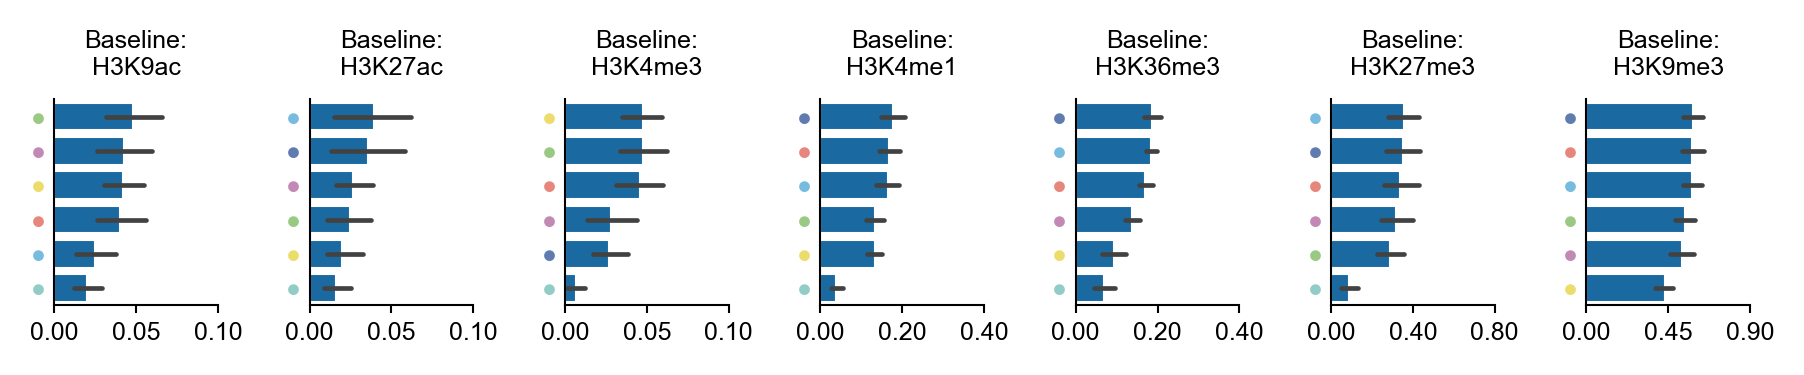

In [92]:

# ============================================================
# Config
# ============================================================
TARGET = "bs"   # "bf" or "bs"

MARKS = [
    "H3K9ac",
    "H3K27ac",
    "H3K4me3",
    "H3K4me1",
    "H3K36me3",
    "H3K27me3",
    "H3K9me3",
]


PAIRWISE_RESULT_FILE = "extra/results/bs_bf_para_keep_marks_indicators.csv"
SINGLE_RESULT_FILE = f"extra/results/one_feature_indicators_{TARGET}_para.csv"

SAVE_FIG = False
OUT_DIR = "extra/figures/marginal_gain_analysis"
# os.makedirs(OUT_DIR, exist_ok=True)
palette = ['#E94C72','#036EB8']

# ============================================================
# Utilities
# ============================================================
def parse_two_marks(keep_marks):
    marks = str(keep_marks).split("_")
    marks = [m for m in marks if m in MARKS]
    if len(marks) != 2:
        return None
    return marks


def safe_divide(numerator, denominator, eps=1e-8):
    return numerator / np.maximum(denominator, eps)


# ============================================================
# 1. Load single-mark results
# ============================================================
single_df = pd.read_csv(SINGLE_RESULT_FILE).copy()

single_df = single_df.rename(
    columns={
        "keep_mark": "mark",
        "auc": "single_auc",
    }
)

single_df = single_df[["eid", "mark", "fold", "single_auc"]].copy()
single_df = single_df[single_df["mark"].isin(MARKS)].copy()
single_df["single_auc"] = single_df["single_auc"] / 100.0


# ============================================================
# 2. Load pairwise results
# ============================================================
pair_df = pd.read_csv(PAIRWISE_RESULT_FILE).copy()
pair_df = pair_df[pair_df["target"] == f"{TARGET}_label"].copy()

pair_df["parsed_marks"] = pair_df["keep_marks"].apply(parse_two_marks)
pair_df = pair_df[pair_df["parsed_marks"].notna()].copy()

pair_df["mark_A"] = pair_df["parsed_marks"].apply(lambda x: x[0])
pair_df["mark_B"] = pair_df["parsed_marks"].apply(lambda x: x[1])
pair_df["pair_auc"] = pair_df["auc"] / 100.0

pair_df = pair_df[
    ["eid", "fold", "keep_marks", "mark_A", "mark_B", "pair_auc"]
].copy()


# ============================================================
# 3. Build directional table:
#    For each pair A+B, generate A -> A+B and B -> A+B
# ============================================================
records = []

for _, row in pair_df.iterrows():
    eid = row["eid"]
    fold = row["fold"]
    mark_A = row["mark_A"]
    mark_B = row["mark_B"]
    pair_auc = row["pair_auc"]
    keep_marks = row["keep_marks"]

    records.append(
        {
            "eid": eid,
            "fold": fold,
            "keep_marks": keep_marks,
            "baseline_mark": mark_A,
            "added_mark": mark_B,
            "pair_auc": pair_auc,
        }
    )

    records.append(
        {
            "eid": eid,
            "fold": fold,
            "keep_marks": keep_marks,
            "baseline_mark": mark_B,
            "added_mark": mark_A,
            "pair_auc": pair_auc,
        }
    )

delta_df = pd.DataFrame(records)


# ============================================================
# 4. Merge single-mark AUCs
# ============================================================
baseline_single = single_df.rename(
    columns={
        "mark": "baseline_mark",
        "single_auc": "baseline_auc",
    }
)

added_single = single_df.rename(
    columns={
        "mark": "added_mark",
        "single_auc": "added_auc",
    }
)

delta_df = delta_df.merge(
    baseline_single,
    on=["eid", "fold", "baseline_mark"],
    how="left",
)

delta_df = delta_df.merge(
    added_single,
    on=["eid", "fold", "added_mark"],
    how="left",
)

if delta_df["baseline_auc"].isna().any():
    raise ValueError("Some baseline single-mark AUC values are missing.")

if delta_df["added_auc"].isna().any():
    raise ValueError("Some added-mark single AUC values are missing.")


# ============================================================
# 5. Compute marginal gain metrics
# ============================================================
# Absolute marginal gain:
# AUC(A+B) - AUC(A)
delta_df["delta_auc"] = delta_df["pair_auc"] - delta_df["baseline_auc"]

# Normalized marginal gain:
# [AUC(A+B) - AUC(A)] / [1 - AUC(A)]
delta_df["normalized_marginal_gain"] = safe_divide(
    delta_df["delta_auc"],
    1.0 - delta_df["baseline_auc"],
)

# # Gain over the better single-mark model:
# # AUC(A+B) - max(AUC(A), AUC(B))
delta_df["best_single_auc"] = delta_df[["baseline_auc", "added_auc"]].max(axis=1)
delta_df["gain_over_best_single"] = (
    delta_df["pair_auc"] - delta_df["best_single_auc"]
)

delta_df["pair_name"] = delta_df.apply(
    lambda r: " + ".join(sorted([r["baseline_mark"], r["added_mark"]])),
    axis=1,
)

# ============================================================
# 7. Plot normalized marginal gain by baseline mark
#    Replace y-axis labels with colored circles
# ============================================================
fig, axes = plt.subplots(
    1,
    len(MARKS),
    figsize=(15.5 / 2.54, 3.4 / 2.54),
)

for idx, baseline_mark in enumerate(MARKS):
    ax = axes[idx]
    sub = delta_df[delta_df["baseline_mark"] == baseline_mark].copy()

    order = (
        sub.groupby("added_mark")["normalized_marginal_gain"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # sns.boxplot(
    #     data=sub,
    #     y="added_mark",
    #     x="normalized_marginal_gain",
    #     order=order,
    #     fliersize=0,
    #     linewidth=0.5,
    #     color="#4C78A8",
    #     ax=ax,
    #     orient="h",
    # )
    sns.barplot(
        data=sub,
        y="added_mark",
        x="normalized_marginal_gain",
        order=order,
        linewidth=0.5,
        color=palette[1],
        ax=ax,
        orient="h",
    )

    # ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(f"Baseline:\n{baseline_mark}", )
    ax.set_xlabel("", )
    ax.set_ylabel("")
    ax.tick_params(axis="x", )
    ax.tick_params(axis="y", length=0)

    # --------------------------------------------------------
    # Replace y-axis mark names with colored circles
    # --------------------------------------------------------
    y_positions = np.arange(len(order))
    circle_labels = ["●" for _ in order]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(circle_labels, )

    for tick_label, mark in zip(ax.get_yticklabels(), order):
        tick_label.set_color(COLOR_MAP.get(mark, "black"))

    # Optional: make x-axis range comparable across panels
    # 根据你的实际结果可以调整
    ax.set_xlim(0, 0.1)
    xticks = [0, 0.05, 0.1]
    xticklabels = [f'{x:.2f}' for x in xticks]
    ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K4me1':
        ax.set_xlim(0, 0.4)
        xticks = [0, 0.2, 0.4]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K4me3':
        xticks = [0, 0.05, 0.1]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K36me3':
        ax.set_xlim(0, 0.4)
        xticks = [0, 0.2, 0.4]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K27me3':
        ax.set_xlim(0, 0.8)
        xticks = [0, 0.4, 0.8]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

    if baseline_mark == 'H3K9me3':
        ax.set_xlim(0, 0.9)
        xticks = [0, 0.45, 0.9]
        xticklabels = [f'{x:.2f}' for x in xticks]
        ax.set_xticks(xticks, labels=xticklabels)

plt.tight_layout()
plt.savefig(
    'extra/figures/v7/Supplementary_Figure6D.eps',
    format='eps', bbox_inches='tight'
)
plt.show()

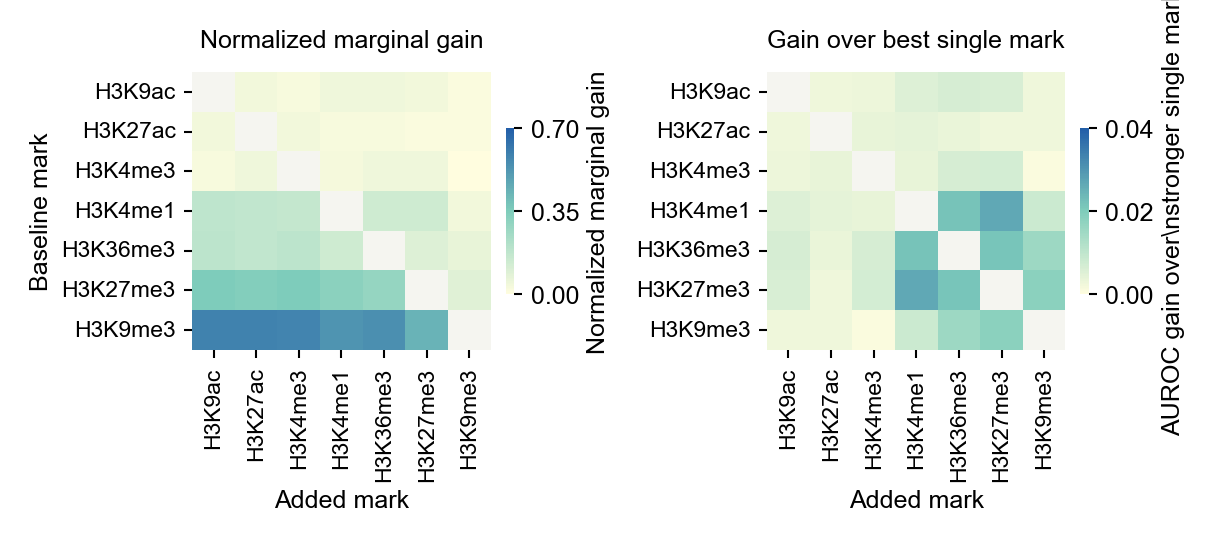

In [93]:
# ============================================================
# 7. Plot heatmaps from delta_df
#    Row: baseline mark
#    Column: added mark
#    Color: mean gain
# ============================================================

# ------------------------------------------------------------
# 7.1 Summarize directional marginal gain
# ------------------------------------------------------------
heatmap_df = (
    delta_df
    .groupby(["baseline_mark", "added_mark"], as_index=False)
    .agg(
        mean_normalized_marginal_gain=("normalized_marginal_gain", "mean"),
        mean_gain_over_best_single=("gain_over_best_single", "mean"),
        mean_delta_auc=("delta_auc", "mean"),
        mean_pair_auc=("pair_auc", "mean"),
        mean_baseline_auc=("baseline_auc", "mean"),
        mean_added_auc=("added_auc", "mean"),
        n=("normalized_marginal_gain", "size"),
    )
)

# ------------------------------------------------------------
# 7.2 Build heatmap matrices
# ------------------------------------------------------------
normalized_gain_mat = (
    heatmap_df
    .pivot(
        index="baseline_mark",
        columns="added_mark",
        values="mean_normalized_marginal_gain",
    )
    .reindex(index=MARKS, columns=MARKS)
)

gain_best_mat = (
    heatmap_df
    .pivot(
        index="baseline_mark",
        columns="added_mark",
        values="mean_gain_over_best_single",
    )
    .reindex(index=MARKS, columns=MARKS)
)

# Set diagonal as NA
for mark in MARKS:
    normalized_gain_mat.loc[mark, mark] = np.nan
    gain_best_mat.loc[mark, mark] = np.nan

# ------------------------------------------------------------
# 7.4 Plot heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, constrained_layout=True, figsize=(10/2.54, 4.3/2.54))

# -------------------------
# Heatmap 1:
# normalized marginal gain
# -------------------------
ax = axes[0]


COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
sns.heatmap(normalized_gain_mat,
            cbar_kws={"shrink": 0.6, "fraction": 0.05,"ticks": [0, 0.35, 0.7],"label":"Normalized marginal gain"},
            vmin=0, vmax=0.7,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=ax)

ax.set_facecolor("#F5F5F0")
ax.set_title("Normalized marginal gain")
ax.set_xlabel("Added mark")
ax.set_ylabel("Baseline mark")
ax.set_xticklabels(MARKS,rotation=90,fontsize=5.5)
ax.set_yticklabels(MARKS,rotation=360, fontsize=5.5)
# color_mark_ticklabels(ax)


# -------------------------
# Heatmap 2:
# gain over best single mark
# -------------------------
ax = axes[1]

COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
sns.heatmap(gain_best_mat,cbar_kws={"shrink": 0.6, "fraction": 0.05,"ticks": [0, 0.02, 0.04],"label": r"AUROC gain over\nstronger single mark",},vmin=0, vmax=0.04,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=ax)


ax.set_facecolor("#F5F5F0")
ax.set_title(r"Gain over best single mark")
ax.set_xlabel("Added mark")
ax.set_ylabel("")
ax.set_xticklabels(MARKS,rotation=90,fontsize=5.5)
ax.set_yticklabels(MARKS,rotation=360, fontsize=5.5)
# color_mark_ticklabels(ax)


# ------------------------------------------------------------
# 7.5 Save and show
# ------------------------------------------------------------
# plt.tight_layout()

plt.savefig(
    "extra/figures/v8/Supplementary_Figure6D_heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
)


plt.show()